In [4]:
import sys
from pathlib import Path

# Add parent directory to path to import lazyfca and utils
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA
from utils import estimate_quality

In [5]:
# Load the metric thresholds data
df = pd.read_csv('threshold_results/old_rice_pr_metric_thresholds.csv')
print(f"Loaded {len(df)} rows")
print(f"Metrics: {df['metric_name'].unique()}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Loaded 5625 rows
Metrics: <StringArray>
[        'opposers_covered',                  'support',
               'error_rate',                'precision',
                     'lift',                    'wracc',
 'balanced_precision_proxy',                'youdens_j',
     'matthews_correlation',         'information_gain',
                'gini_gain',           'log_odds_ratio',
              'chi_squared',                   'g_test',
       'interval_tightness',       'description_volume',
         'simplicity_prior',  'query_binary_similarity',
 'query_numeric_similarity',         'query_similarity',
 'query_weighted_precision',     'query_weighted_wracc',
                'stability',               'robustness',
          'delta_stability']
Length: 25, dtype: str

Columns: ['metric_name', 'pos_threshold', 'neg_threshold', 'num_pos_classifiers_passing', 'num_neg_classifiers_passing', 'avg_positive_classifications', 'avg_negative_classifications', 'Accuracy', 'Precision', 'Recall', 'AU

,metric_name,pos_threshold,neg_threshold,num_pos_classifiers_passing,num_neg_classifiers_passing,avg_positive_classifications,avg_negative_classifications,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,opposers_covered,0.0,0.0,194004,228460,509.19685,599.632546,0.905512,0.867052,0.920245,0.978893,0.892857,150,195,23,13,0.894495,0.937500,0.105505,0.132948
1,opposers_covered,0.0,38.0,194004,444354,509.19685,1166.283465,0.868766,0.982906,0.705521,0.977627,0.821429,115,216,2,48,0.990826,0.818182,0.009174,0.017094
2,opposers_covered,0.0,76.0,194004,460895,509.19685,1209.698163,0.847769,0.981651,0.656442,0.977261,0.786765,107,216,2,56,0.990826,0.794118,0.009174,0.018349
3,opposers_covered,0.0,114.0,194004,467032,509.19685,1225.805774,0.845144,0.981481,0.650307,0.977233,0.782288,106,216,2,57,0.990826,0.791209,0.009174,0.018519
4,opposers_covered,0.0,152.0,194004,470062,509.19685,1233.758530,0.845144,0.981481,0.650307,0.977149,0.782288,106,216,2,57,0.990826,0.791209,0.009174,0.018519


In [6]:
def plot_both_thresholds_vs_f1(df, metric_name):
    """
    Plot both positive and negative threshold vs max F1-score side by side for a given metric.
    
    Args:
        df: DataFrame with metric threshold results
        metric_name: Name of the metric to plot
    """
    # Filter data for this metric
    metric_df = df[df['metric_name'] == metric_name].copy()
    
    if len(metric_df) == 0:
        print(f"No data found for metric: {metric_name}")
        return
    
    # Create figure with 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    
    # Process both threshold types
    for idx, (threshold_type, ax) in enumerate(zip(['pos', 'neg'], axes)):
        if threshold_type == 'pos':
            threshold_col = 'pos_threshold'
            avg_classifications_col = 'avg_positive_classifications'
            other_avg_classifications_col = 'avg_negative_classifications'
            title_label = 'Positive'
        else:
            threshold_col = 'neg_threshold'
            avg_classifications_col = 'avg_negative_classifications'
            other_avg_classifications_col = 'avg_positive_classifications'
            title_label = 'Negative'
        
        # Group by threshold and get max F1-score
        result_rows = []
        for threshold in metric_df[threshold_col].unique():
            subset = metric_df[metric_df[threshold_col] == threshold]
            max_f1_idx = subset['F1-score'].idxmax()
            max_f1_row = subset.loc[max_f1_idx]
            result_rows.append({
                threshold_col: threshold,
                'F1-score': max_f1_row['F1-score'],
                avg_classifications_col: int(max_f1_row[avg_classifications_col]),
                other_avg_classifications_col: int(max_f1_row[other_avg_classifications_col]),
            })
        
        plot_df = pd.DataFrame(result_rows).sort_values(threshold_col)
        
        thresholds = plot_df[threshold_col].values
        f1_scores = plot_df['F1-score'].values
        main_avg_classifications = plot_df[avg_classifications_col].values
        other_avg_classifications = plot_df[other_avg_classifications_col].values
        
        # Plot on the subplot
        ax.plot(thresholds, f1_scores, marker='o', linewidth=2, markersize=6, color='blue')
        
        # Add annotations for each point
        for i, (x, y) in enumerate(zip(thresholds, f1_scores)):
            # Main avg classifications (green) above the point
            ax.annotate(f'{main_avg_classifications[i]}', 
                        xy=(x, y), 
                        xytext=(0, 12),
                        textcoords='offset points',
                        ha='center',
                        fontsize=9,
                        color='green',
                        weight='bold')
            
            # Other avg classifications (red) below the point
            ax.annotate(f'{other_avg_classifications[i]}', 
                        xy=(x, y), 
                        xytext=(0, -18),
                        textcoords='offset points',
                        ha='center',
                        fontsize=9,
                        color='red',
                        weight='bold')
        
        ax.set_xlabel(f'{title_label} Threshold', fontsize=12)
        ax.set_ylabel('Max F1 Score', fontsize=12)
        ax.set_title(f'{title_label} Threshold Analysis\n(Green = Avg {title_label} Class., Red = Avg {"Negative" if threshold_type == "pos" else "Positive"} Class.)', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Show best threshold info
        best_idx = np.argmax(f1_scores)
        print(f"\n{title_label} Threshold Analysis:")
        print(f"  Best threshold: {thresholds[best_idx]:.6f}")
        print(f"  Max F1 score: {f1_scores[best_idx]:.6f}")
        print(f"  Avg {title_label.lower()} classifications: {main_avg_classifications[best_idx]}")
        print(f"  Avg {'negative' if threshold_type == 'pos' else 'positive'} classifications: {other_avg_classifications[best_idx]}")
    
    fig.suptitle(f'Threshold Analysis for {metric_name}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

In [7]:
# Get unique metrics in the dataset
metrics = df['metric_name'].unique()
print(f"Available metrics ({len(metrics)}):")
for i, metric in enumerate(metrics, 1):
    print(f"  {i}. {metric}")

Available metrics (25):
  1. opposers_covered
  2. support
  3. error_rate
  4. precision
  5. lift
  6. wracc
  7. balanced_precision_proxy
  8. youdens_j
  9. matthews_correlation
  10. information_gain
  11. gini_gain
  12. log_odds_ratio
  13. chi_squared
  14. g_test
  15. interval_tightness
  16. description_volume
  17. simplicity_prior
  18. query_binary_similarity
  19. query_numeric_similarity
  20. query_similarity
  21. query_weighted_precision
  22. query_weighted_wracc
  23. stability
  24. robustness
  25. delta_stability



Metric: opposers_covered

Positive Threshold Analysis:
  Best threshold: 56.214286
  Max F1 score: 0.916129
  Avg positive classifications: 992
  Avg negative classifications: 1166

Negative Threshold Analysis:
  Best threshold: 38.000000
  Max F1 score: 0.916129
  Avg negative classifications: 1166
  Avg positive classifications: 992


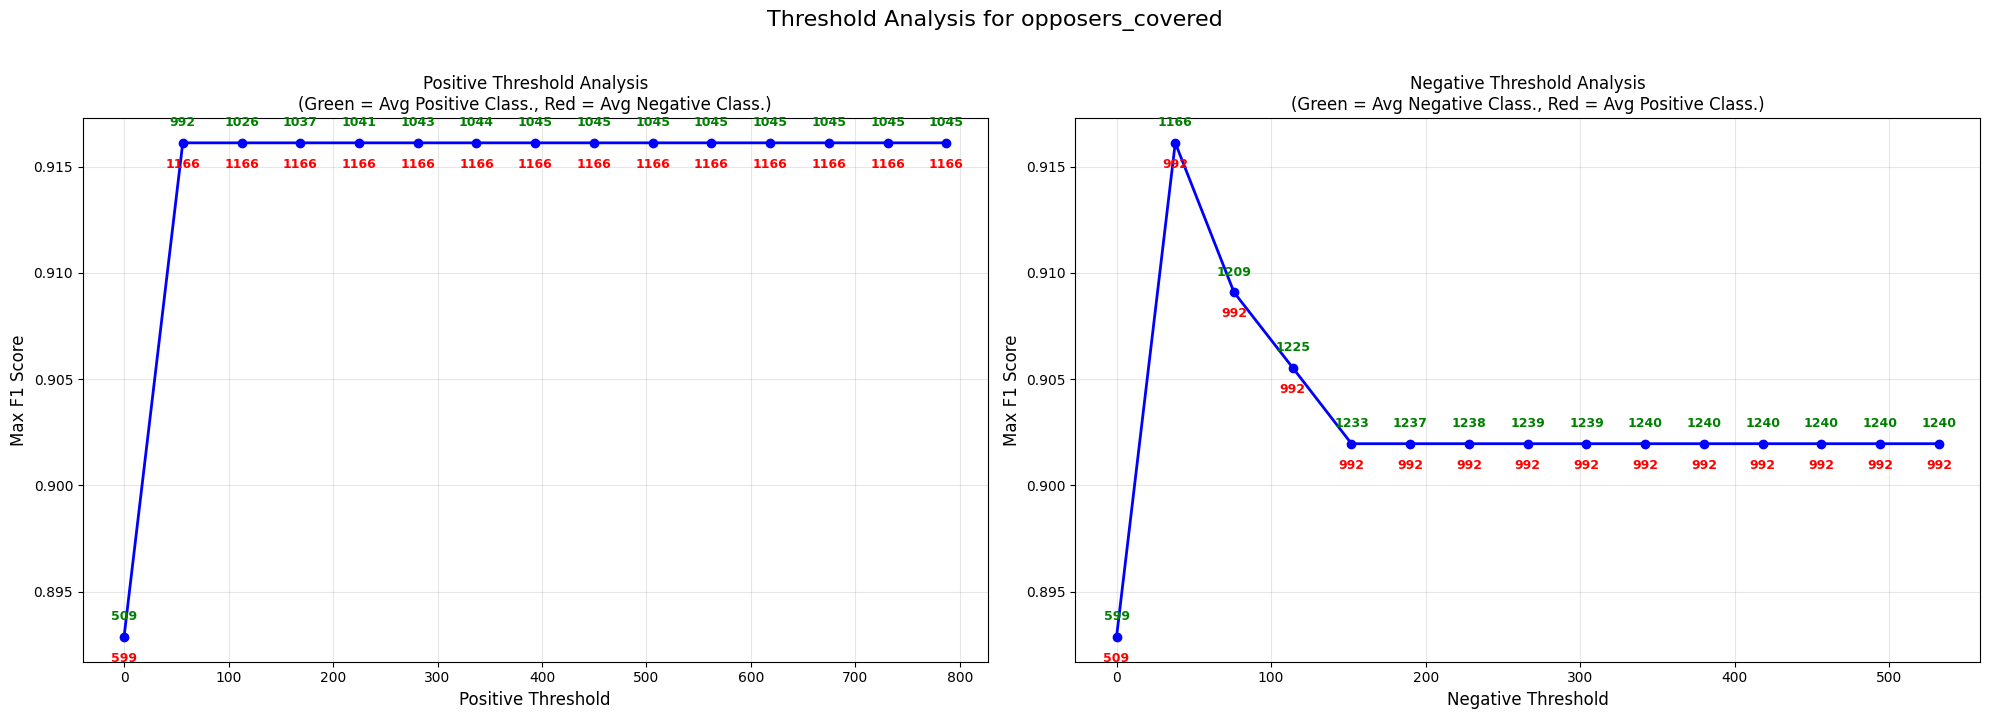


Metric: support

Positive Threshold Analysis:
  Best threshold: 0.000682
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.001019
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


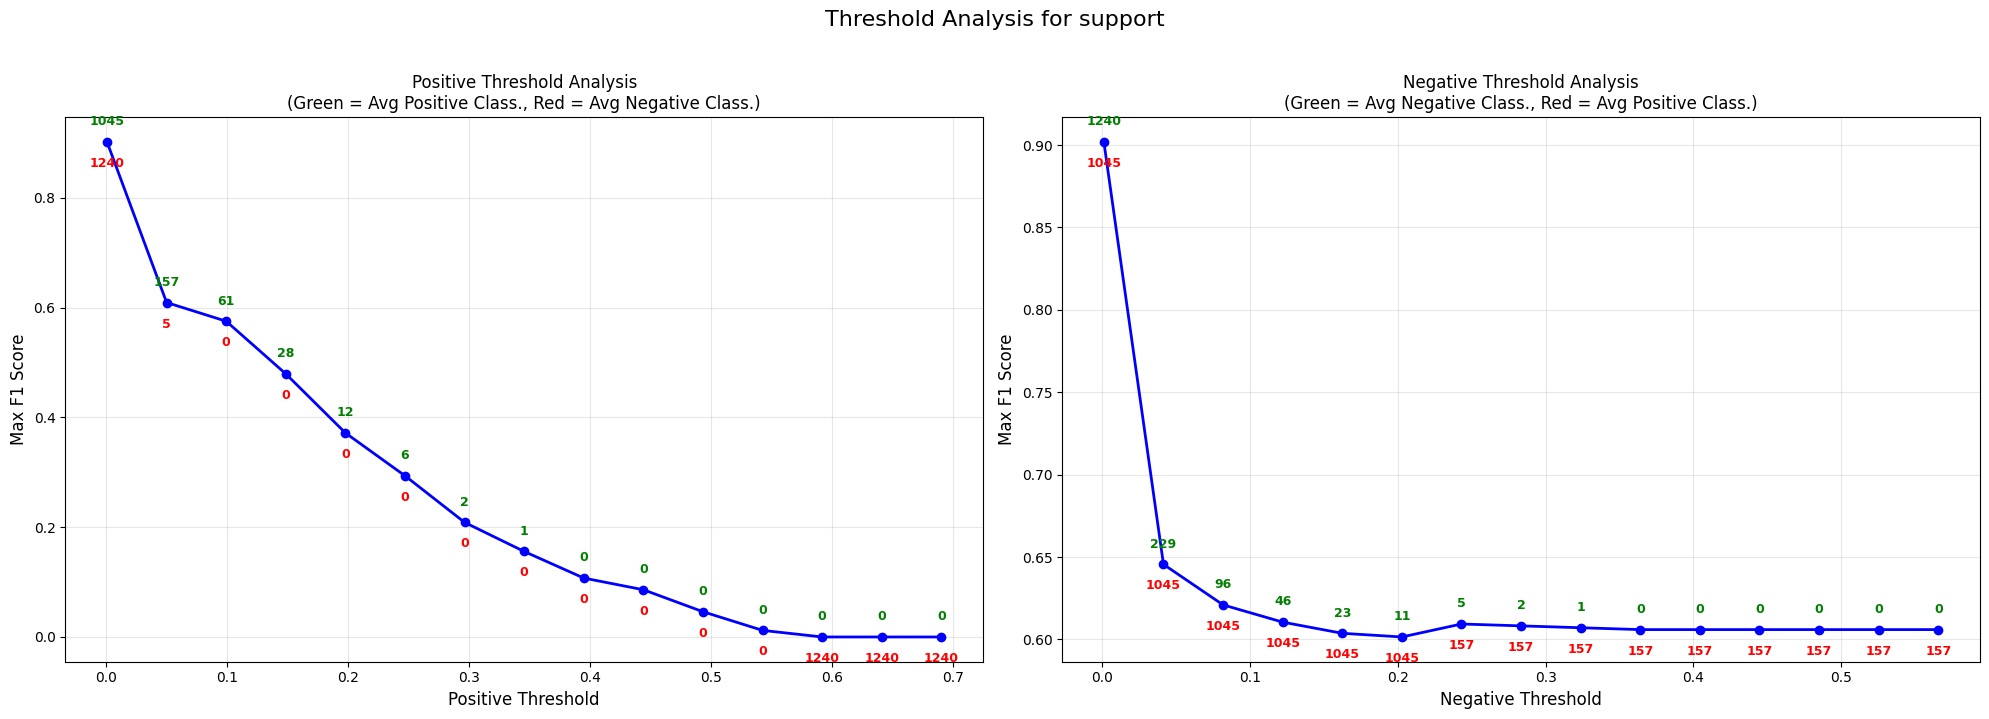


Metric: error_rate

Positive Threshold Analysis:
  Best threshold: 0.028652
  Max F1 score: 0.916129
  Avg positive classifications: 992
  Avg negative classifications: 1166

Negative Threshold Analysis:
  Best threshold: 0.025903
  Max F1 score: 0.916129
  Avg negative classifications: 1166
  Avg positive classifications: 992


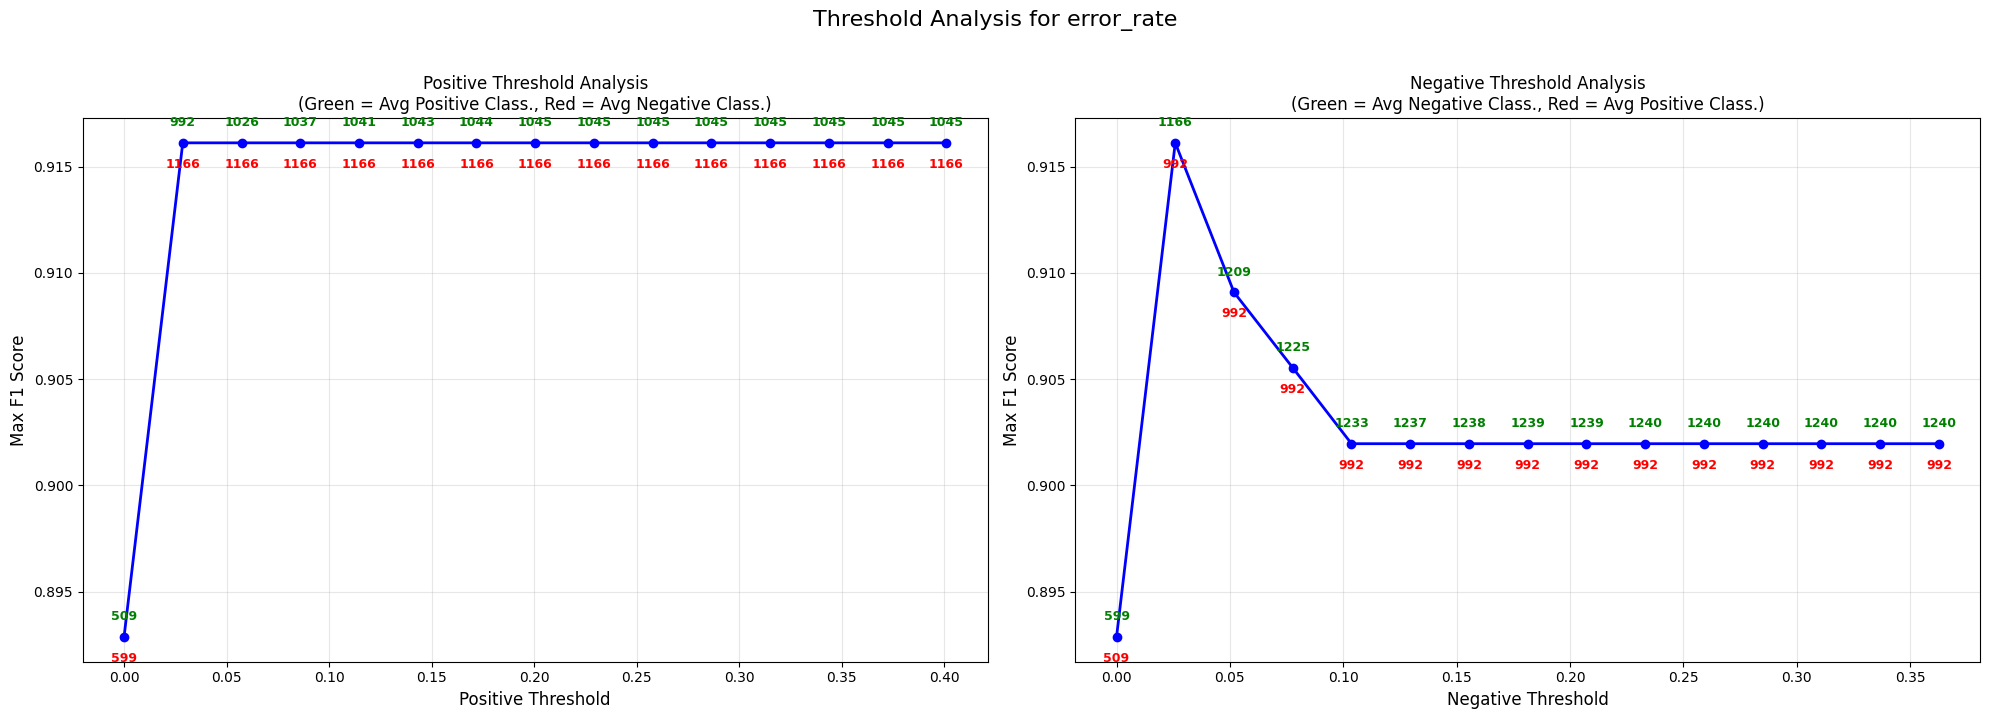


Metric: precision

Positive Threshold Analysis:
  Best threshold: 0.500000
  Max F1 score: 0.925466
  Avg positive classifications: 1045
  Avg negative classifications: 1167

Negative Threshold Analysis:
  Best threshold: 0.682540
  Max F1 score: 0.925466
  Avg negative classifications: 1167
  Avg positive classifications: 1045


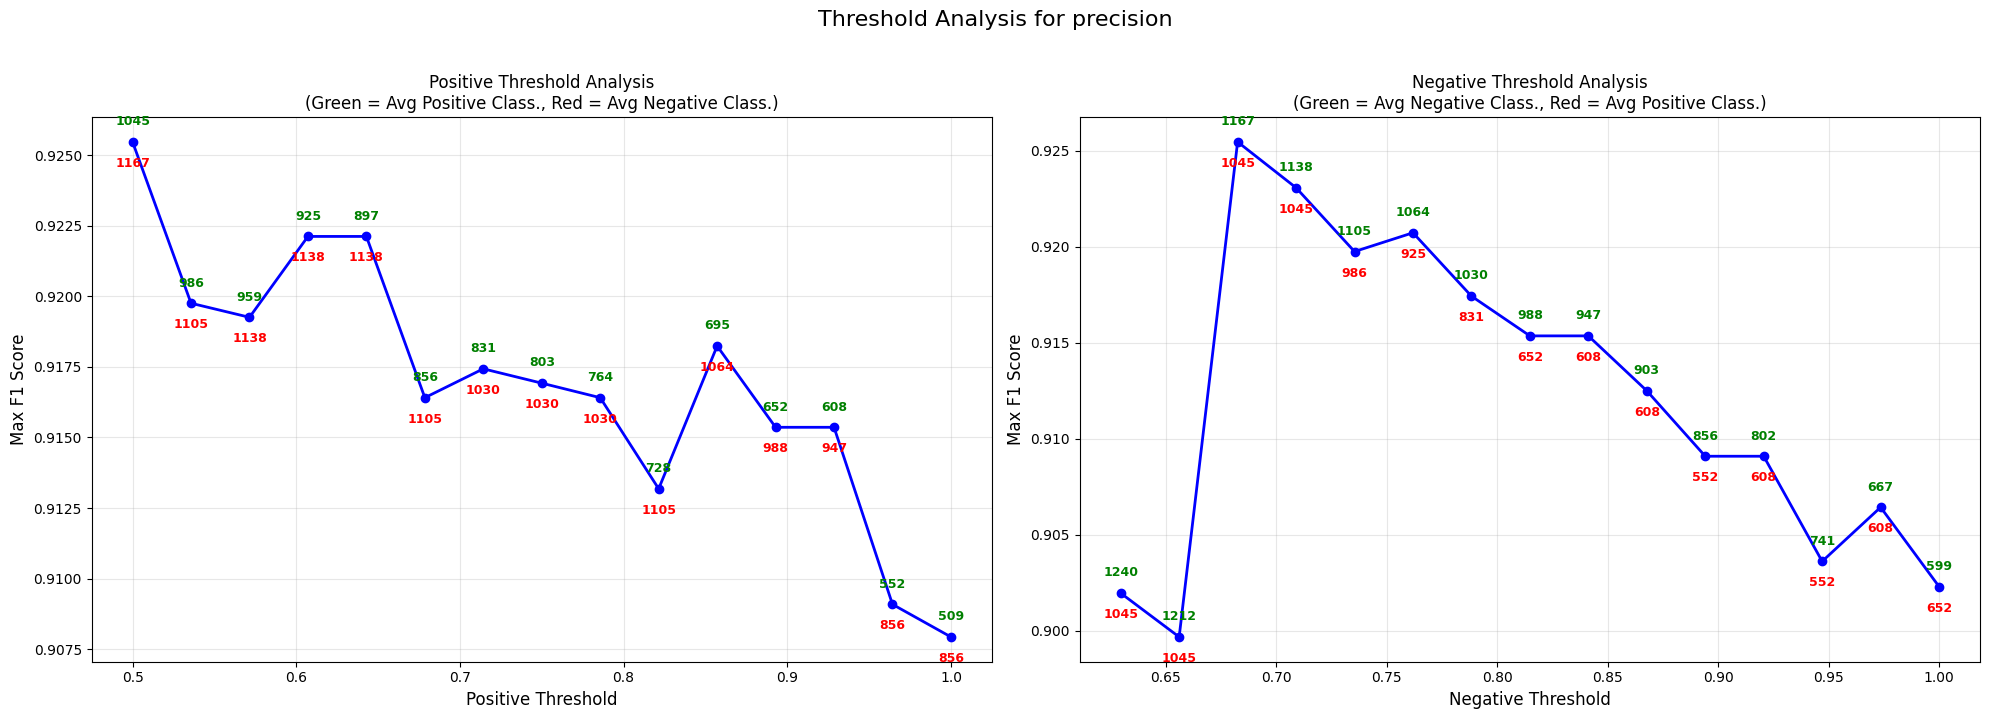


Metric: lift

Positive Threshold Analysis:
  Best threshold: 1.168712
  Max F1 score: 0.925466
  Avg positive classifications: 1045
  Avg negative classifications: 1167

Negative Threshold Analysis:
  Best threshold: 1.192879
  Max F1 score: 0.925466
  Avg negative classifications: 1167
  Avg positive classifications: 1045


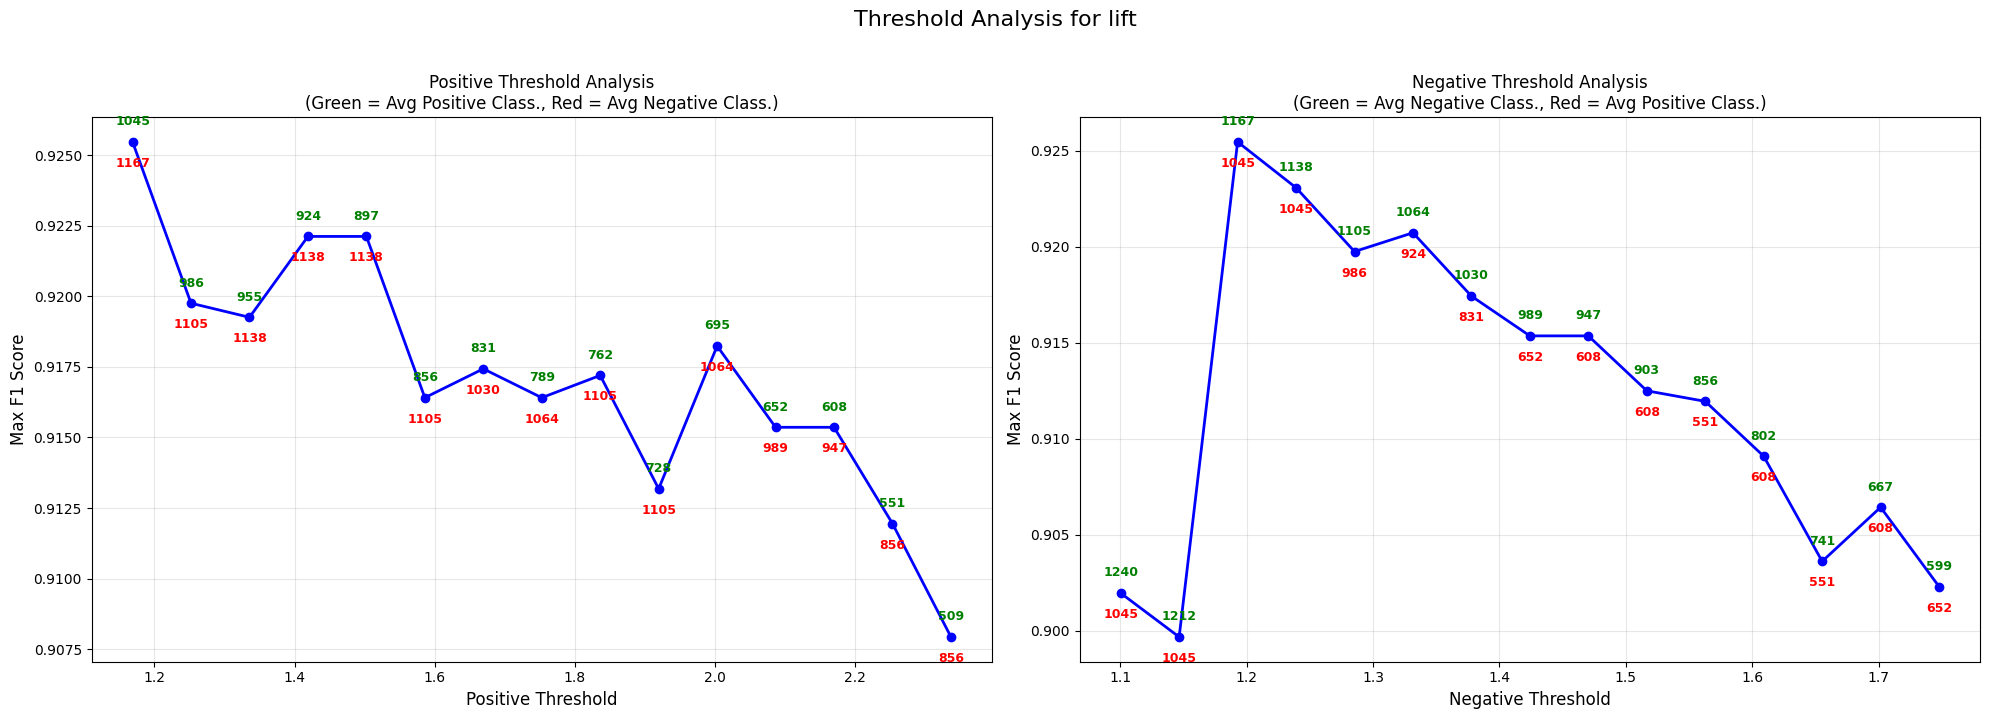


Metric: wracc

Positive Threshold Analysis:
  Best threshold: 0.000042
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.000083
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


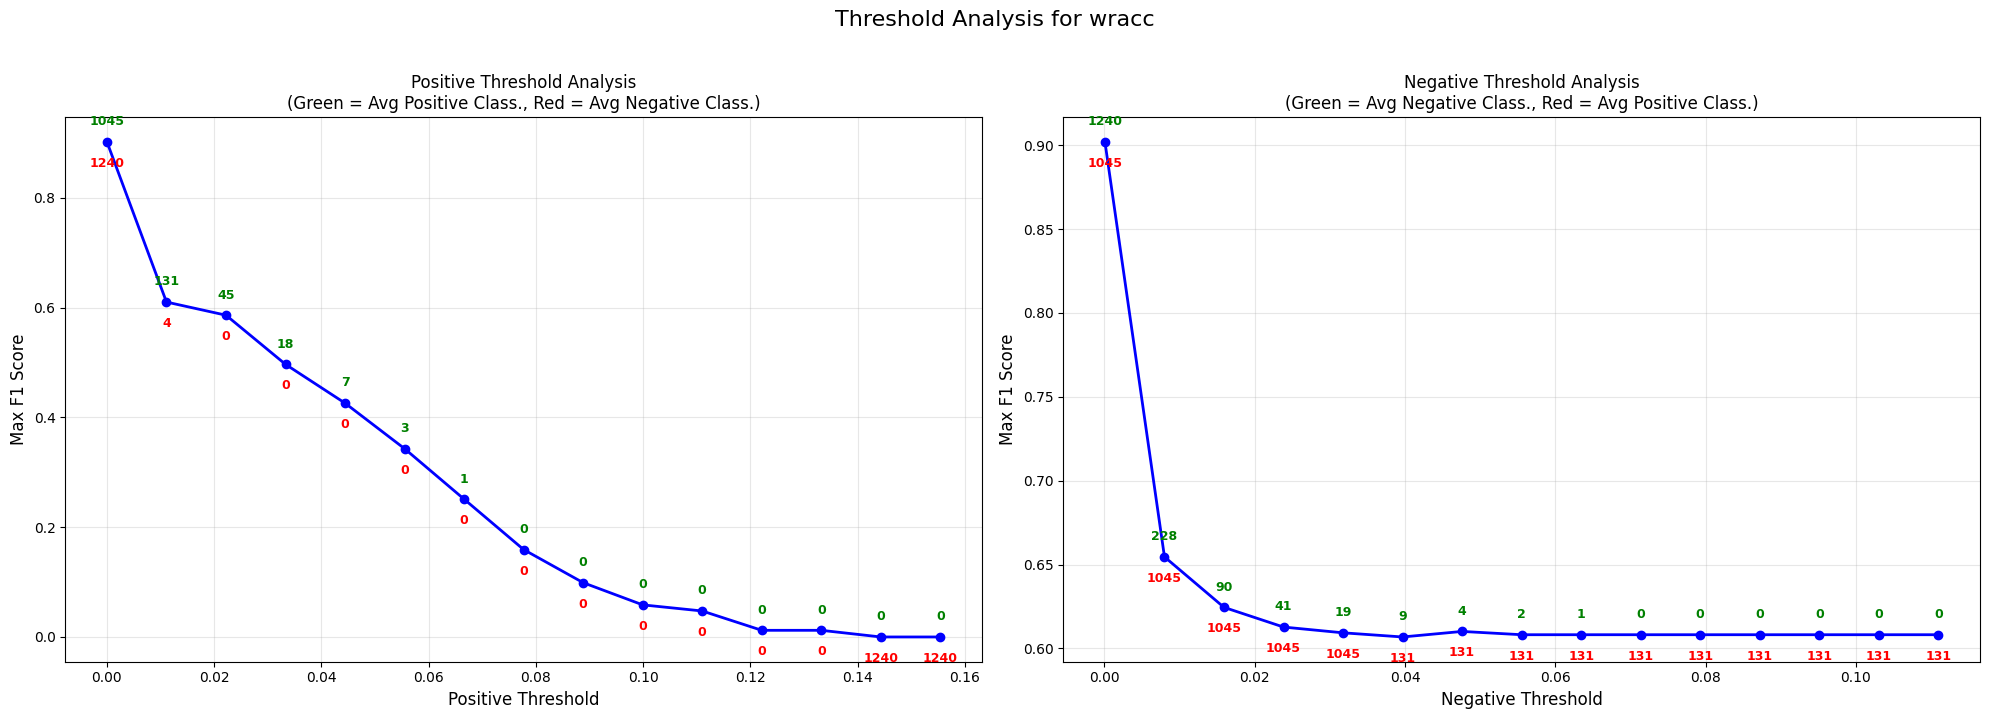


Metric: balanced_precision_proxy

Positive Threshold Analysis:
  Best threshold: 0.000172
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.000338
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


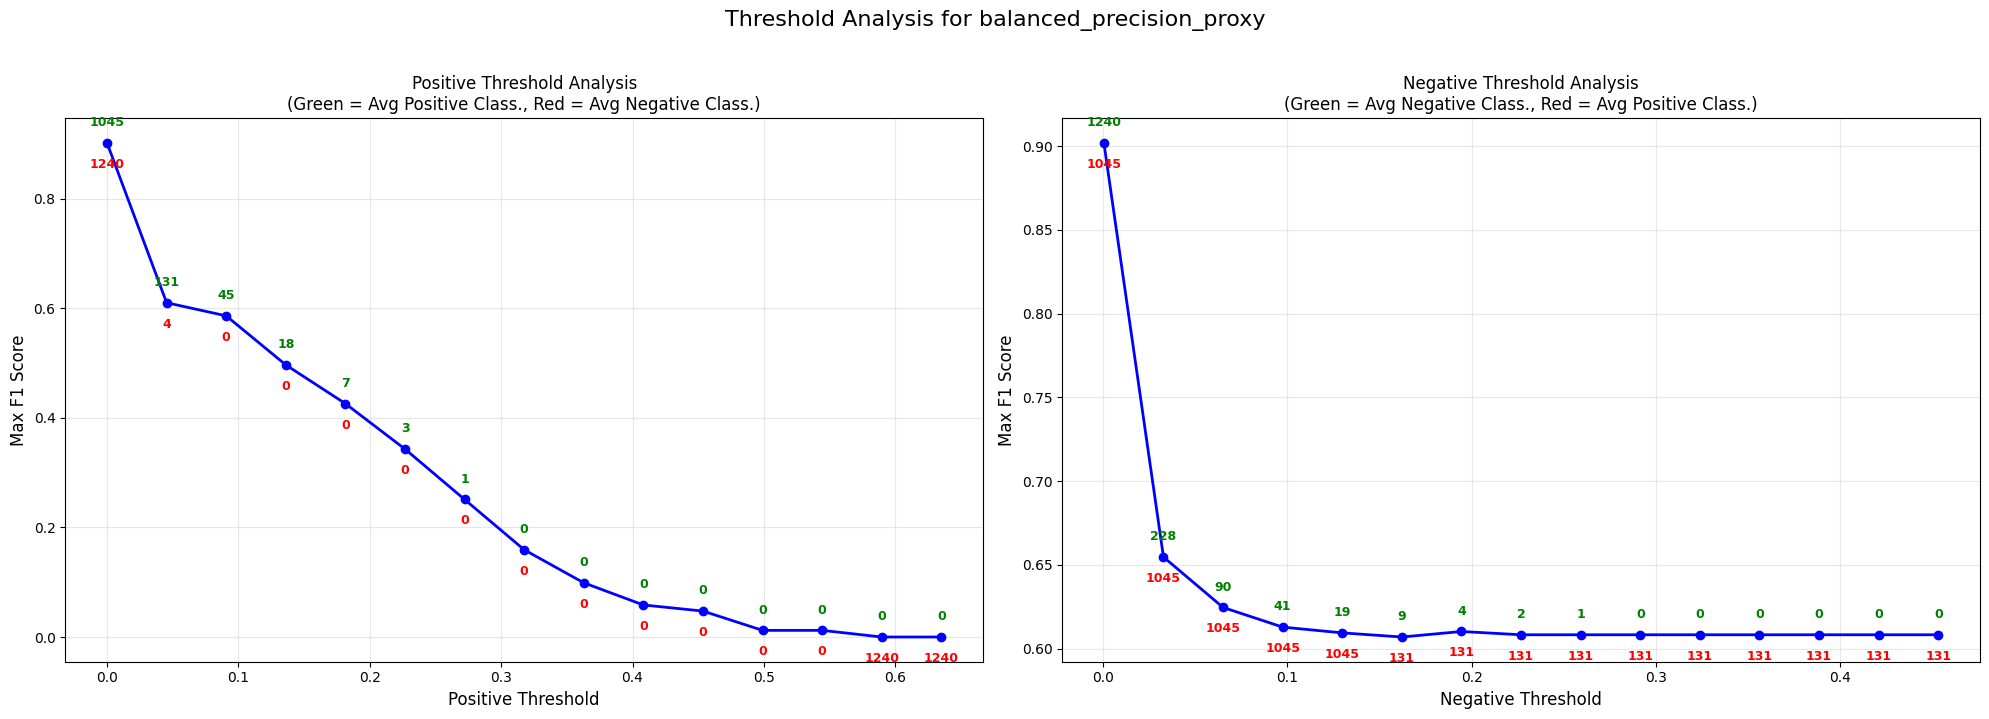


Metric: youdens_j

Positive Threshold Analysis:
  Best threshold: 0.000172
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.000338
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


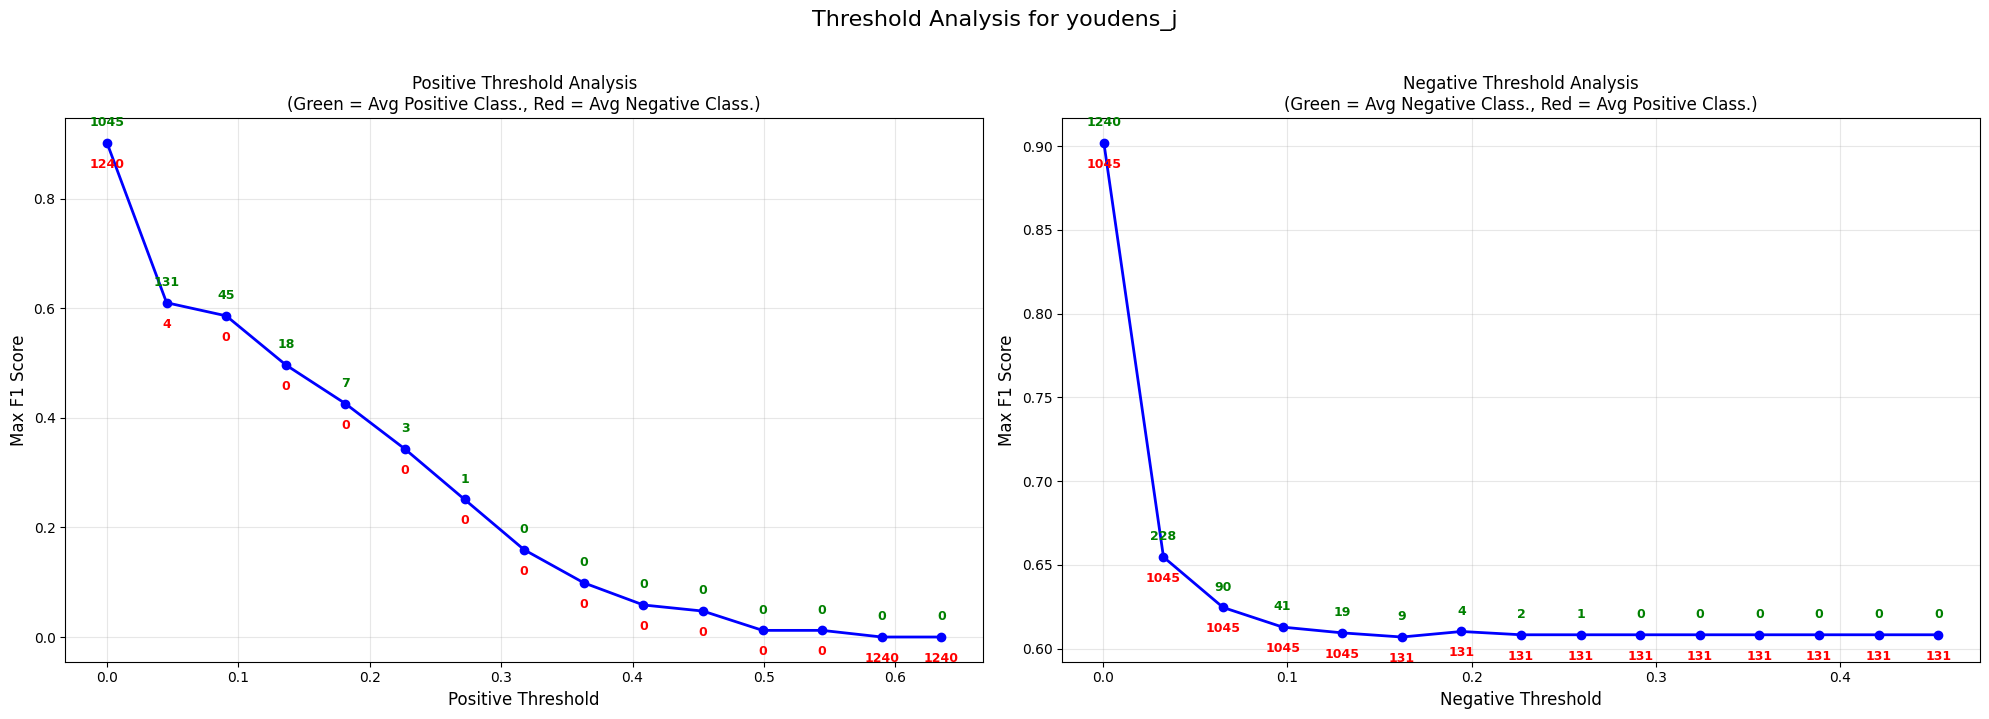


Metric: matthews_correlation

Positive Threshold Analysis:
  Best threshold: 0.003524
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.005651
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


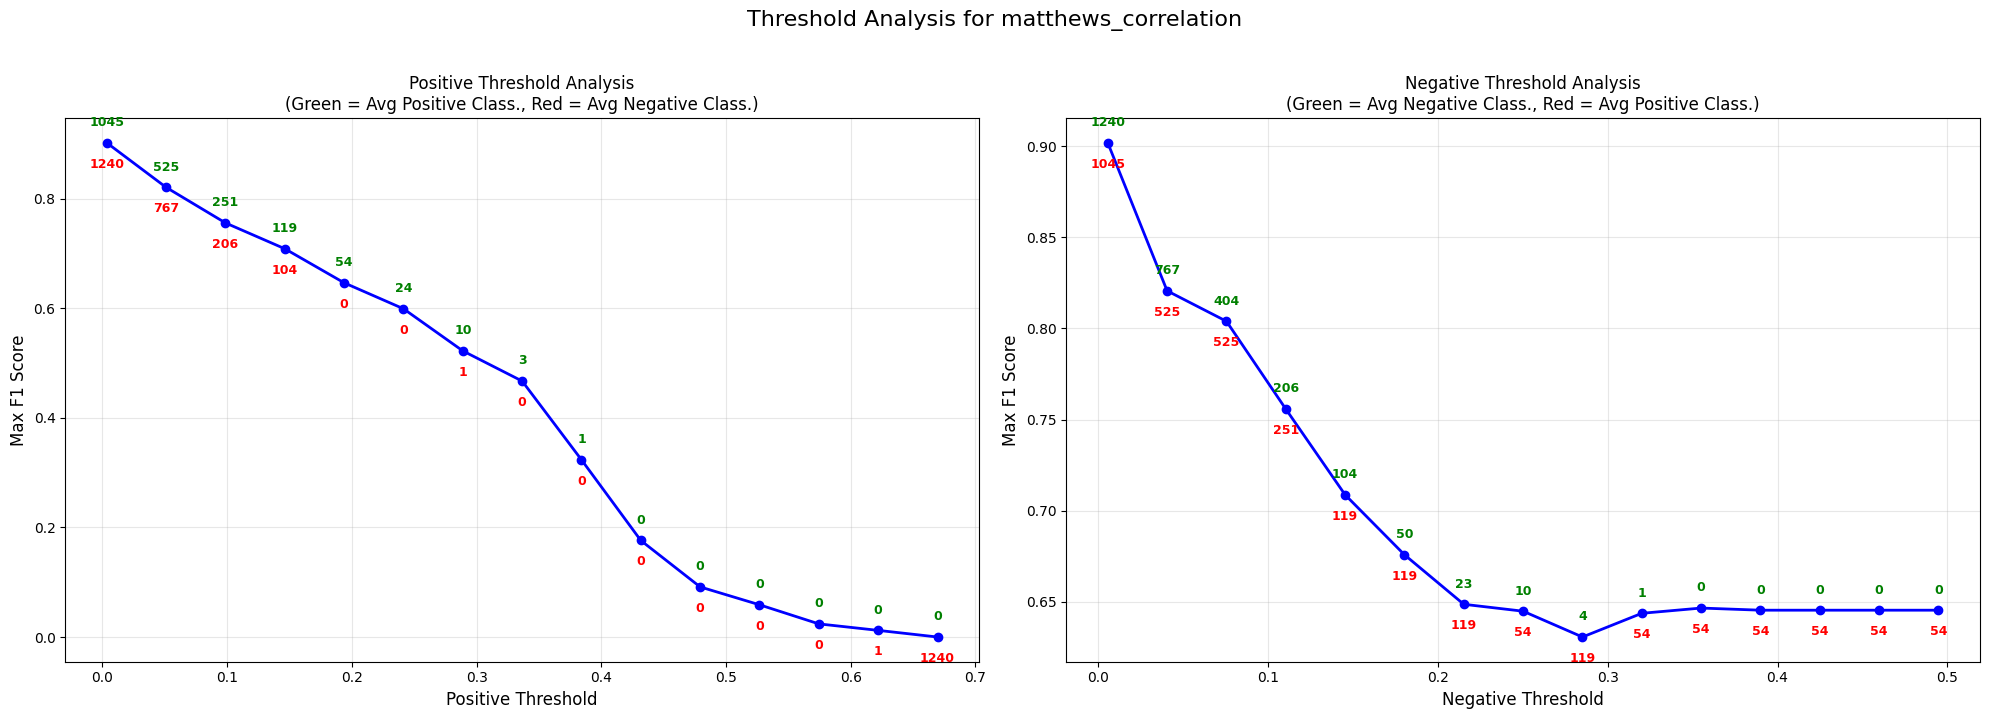


Metric: information_gain

Positive Threshold Analysis:
  Best threshold: 0.000009
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.000024
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


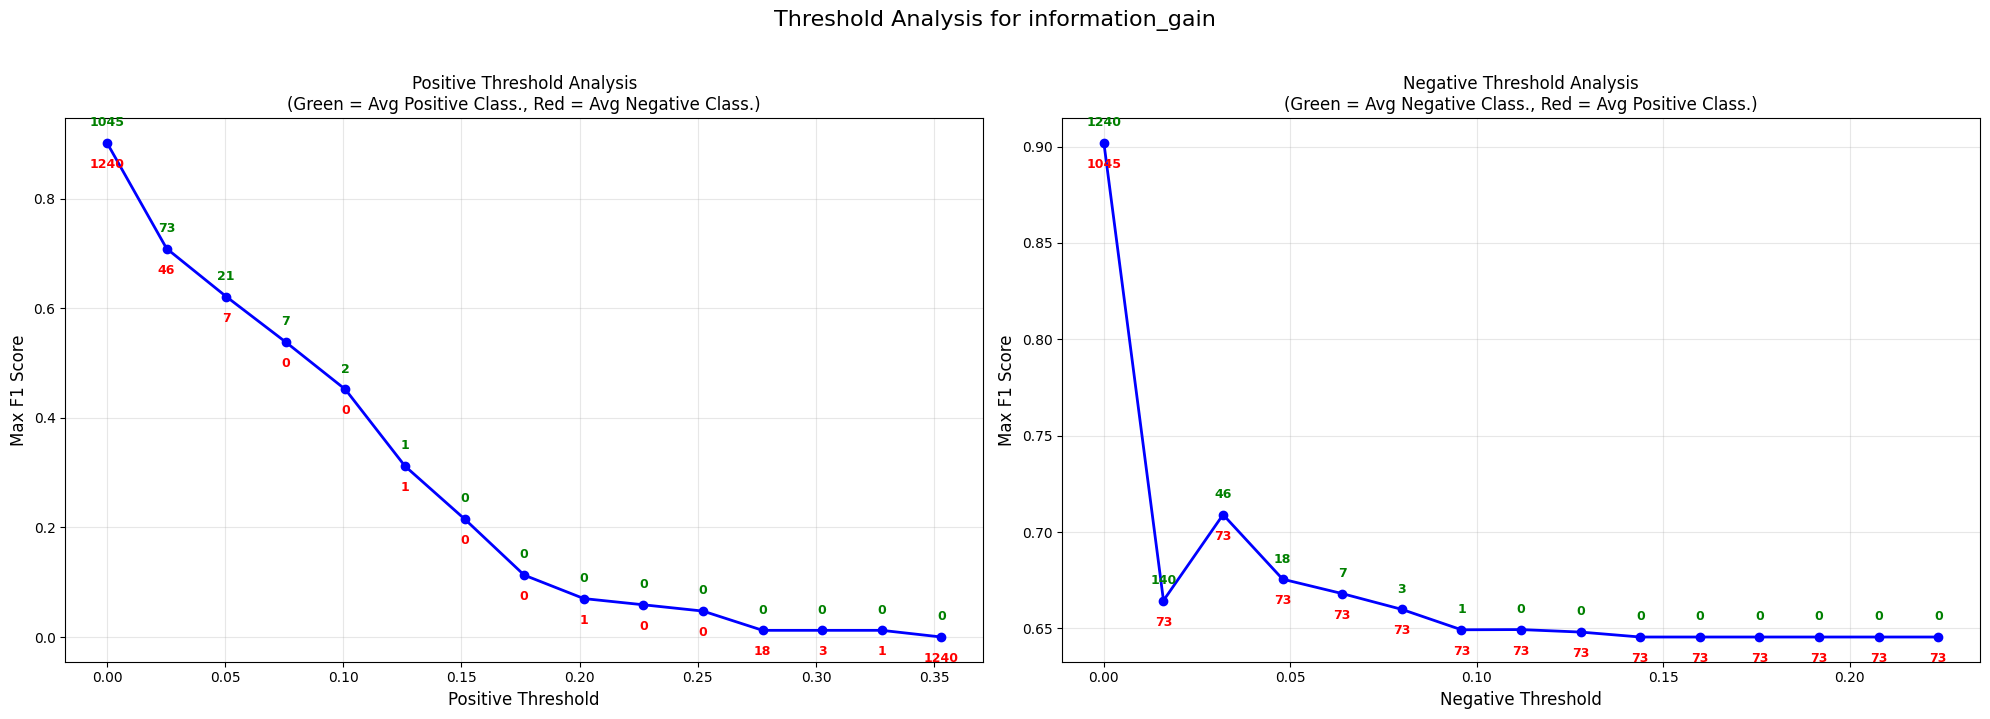


Metric: gini_gain

Positive Threshold Analysis:
  Best threshold: 0.000006
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.000016
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


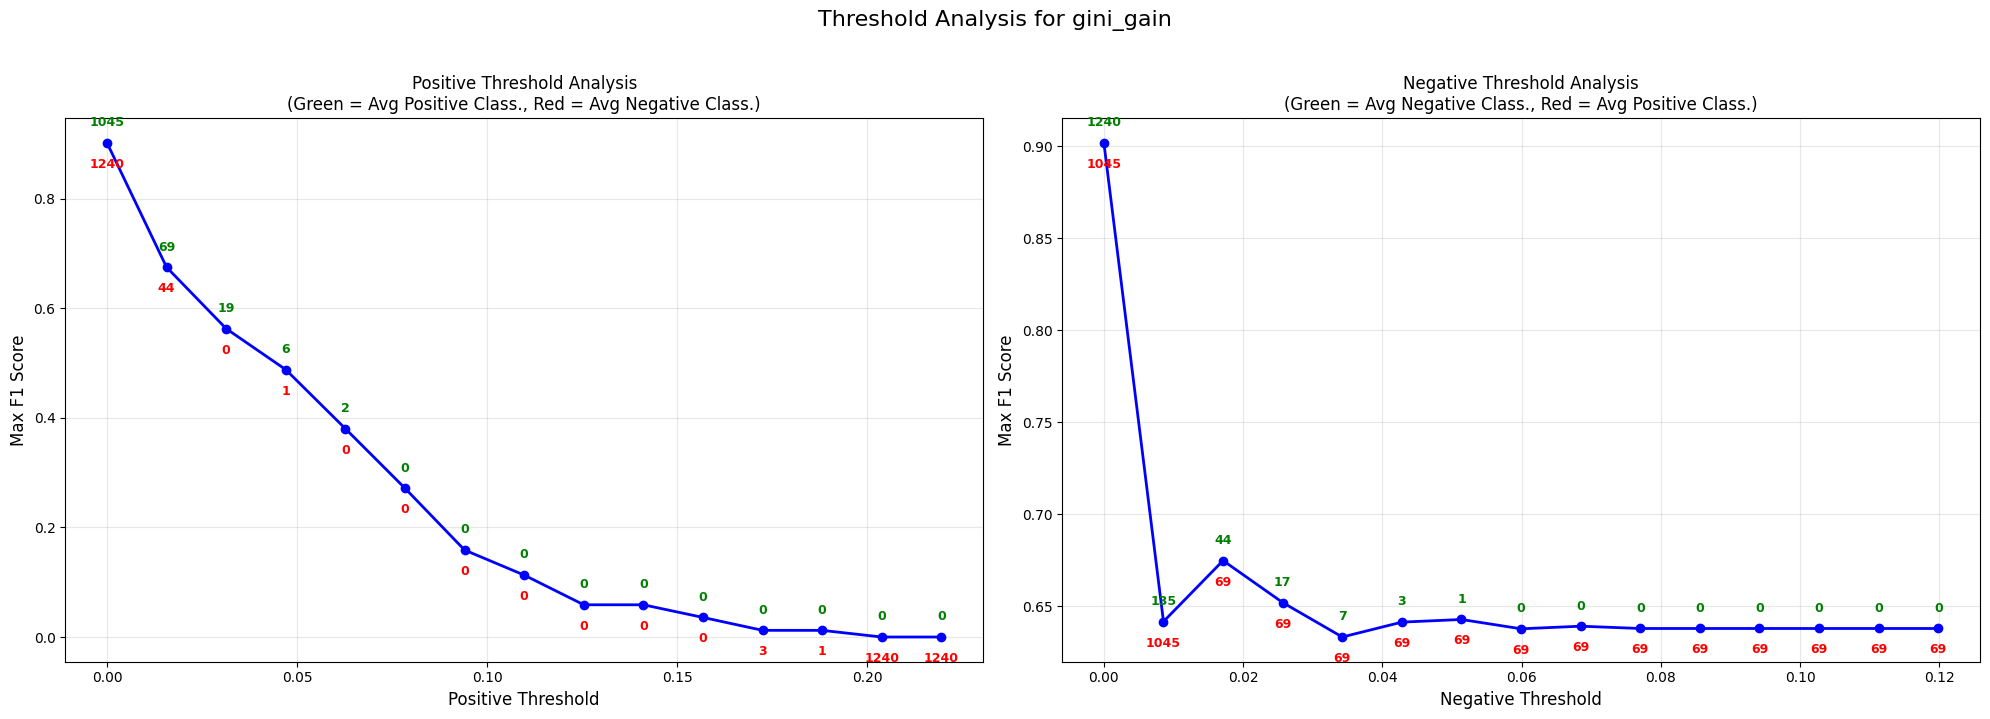


Metric: log_odds_ratio

Positive Threshold Analysis:
  Best threshold: 53.571429
  Max F1 score: 0.909639
  Avg positive classifications: 63
  Avg negative classifications: 111

Negative Threshold Analysis:
  Best threshold: 65.476190
  Max F1 score: 0.909639
  Avg negative classifications: 111
  Avg positive classifications: 63


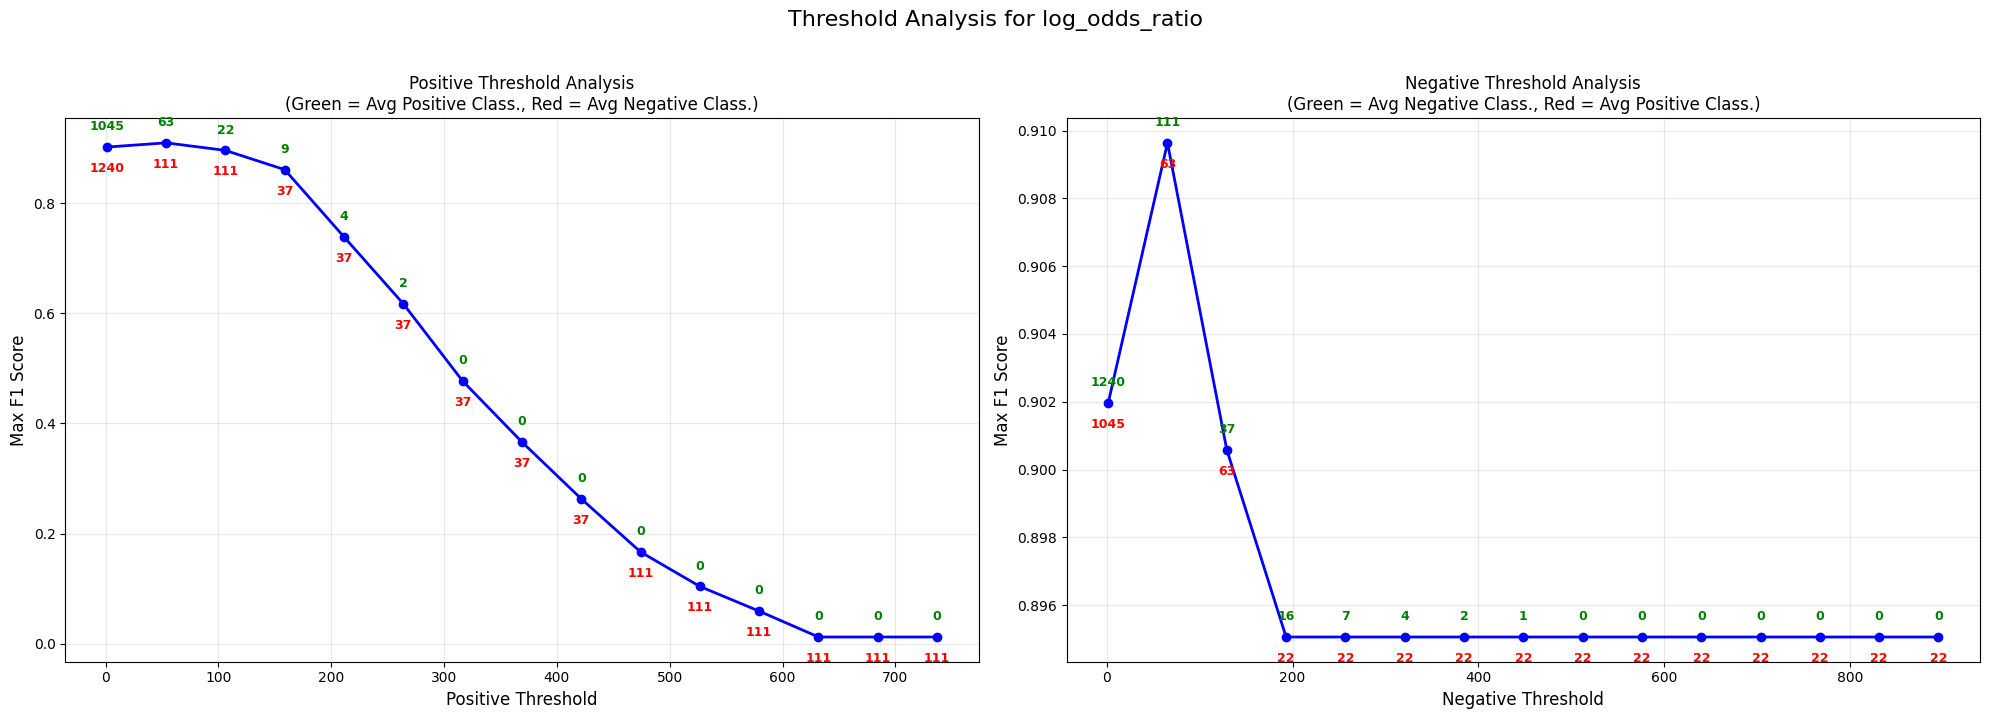


Metric: chi_squared

Positive Threshold Analysis:
  Best threshold: 0.042590
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.109512
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


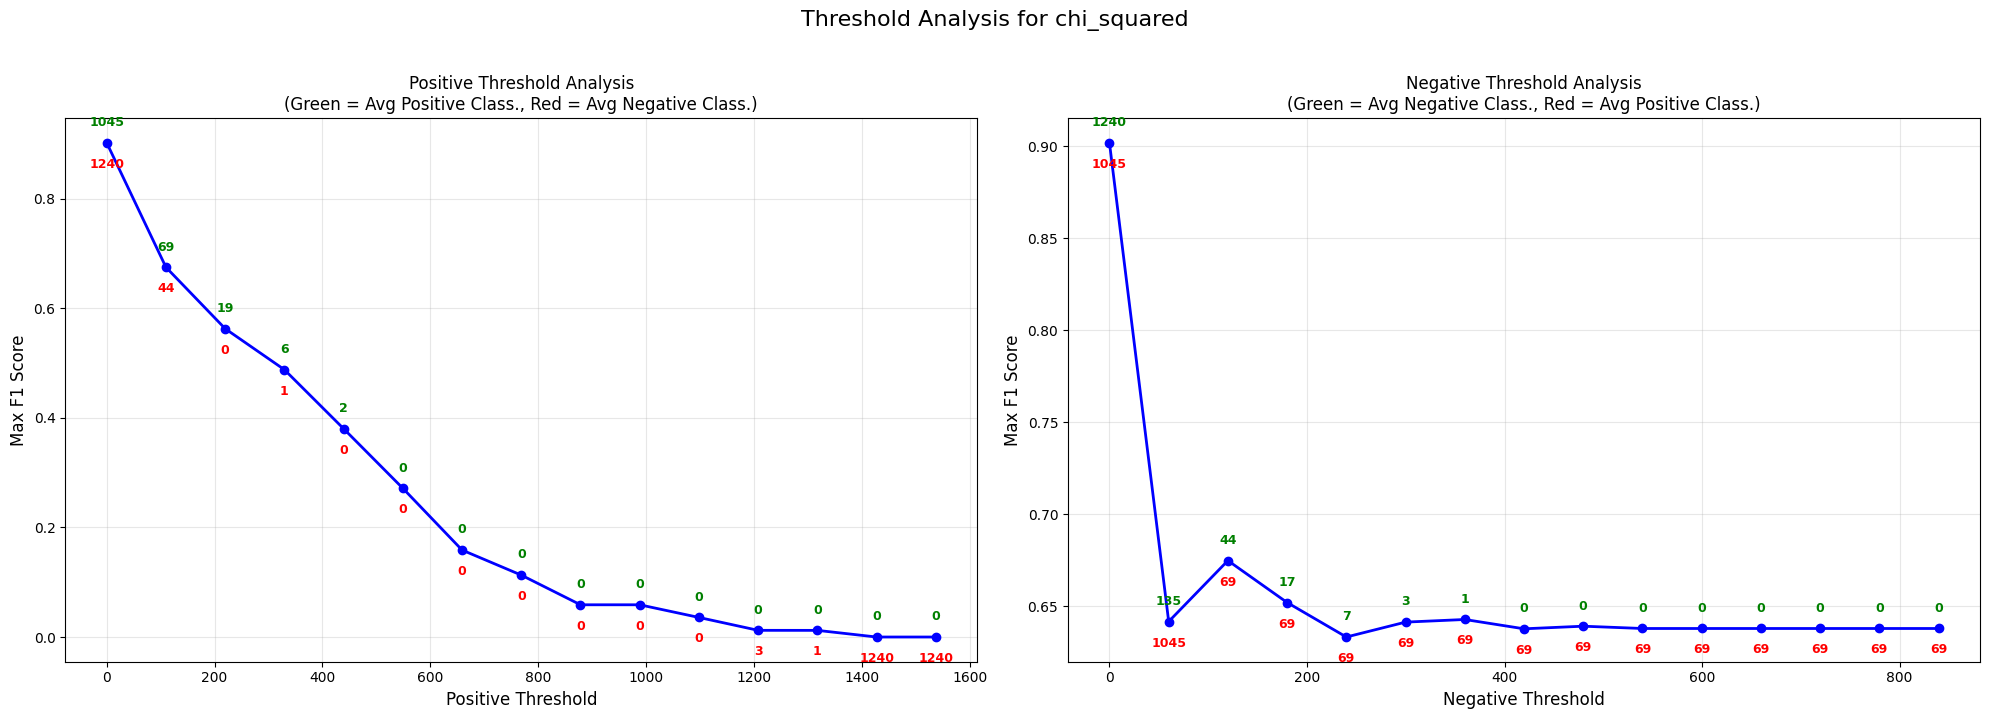


Metric: g_test

Positive Threshold Analysis:
  Best threshold: 0.042143
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.112326
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


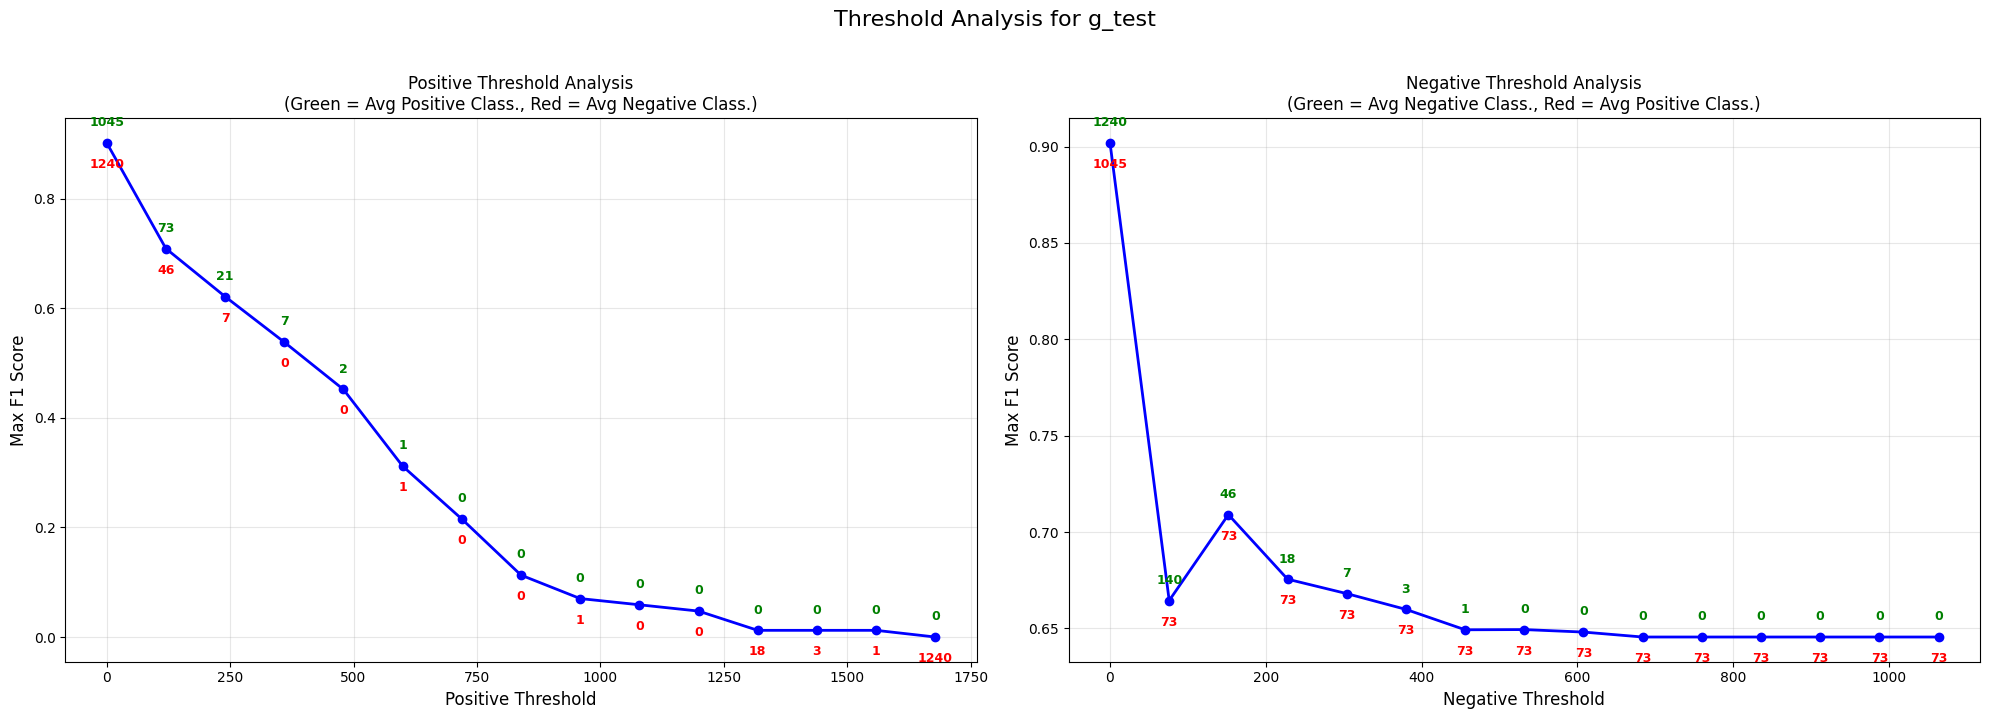


Metric: interval_tightness

Positive Threshold Analysis:
  Best threshold: 0.343262
  Max F1 score: 0.914286
  Avg positive classifications: 1045
  Avg negative classifications: 1136

Negative Threshold Analysis:
  Best threshold: 0.711245
  Max F1 score: 0.914286
  Avg negative classifications: 1136
  Avg positive classifications: 1045


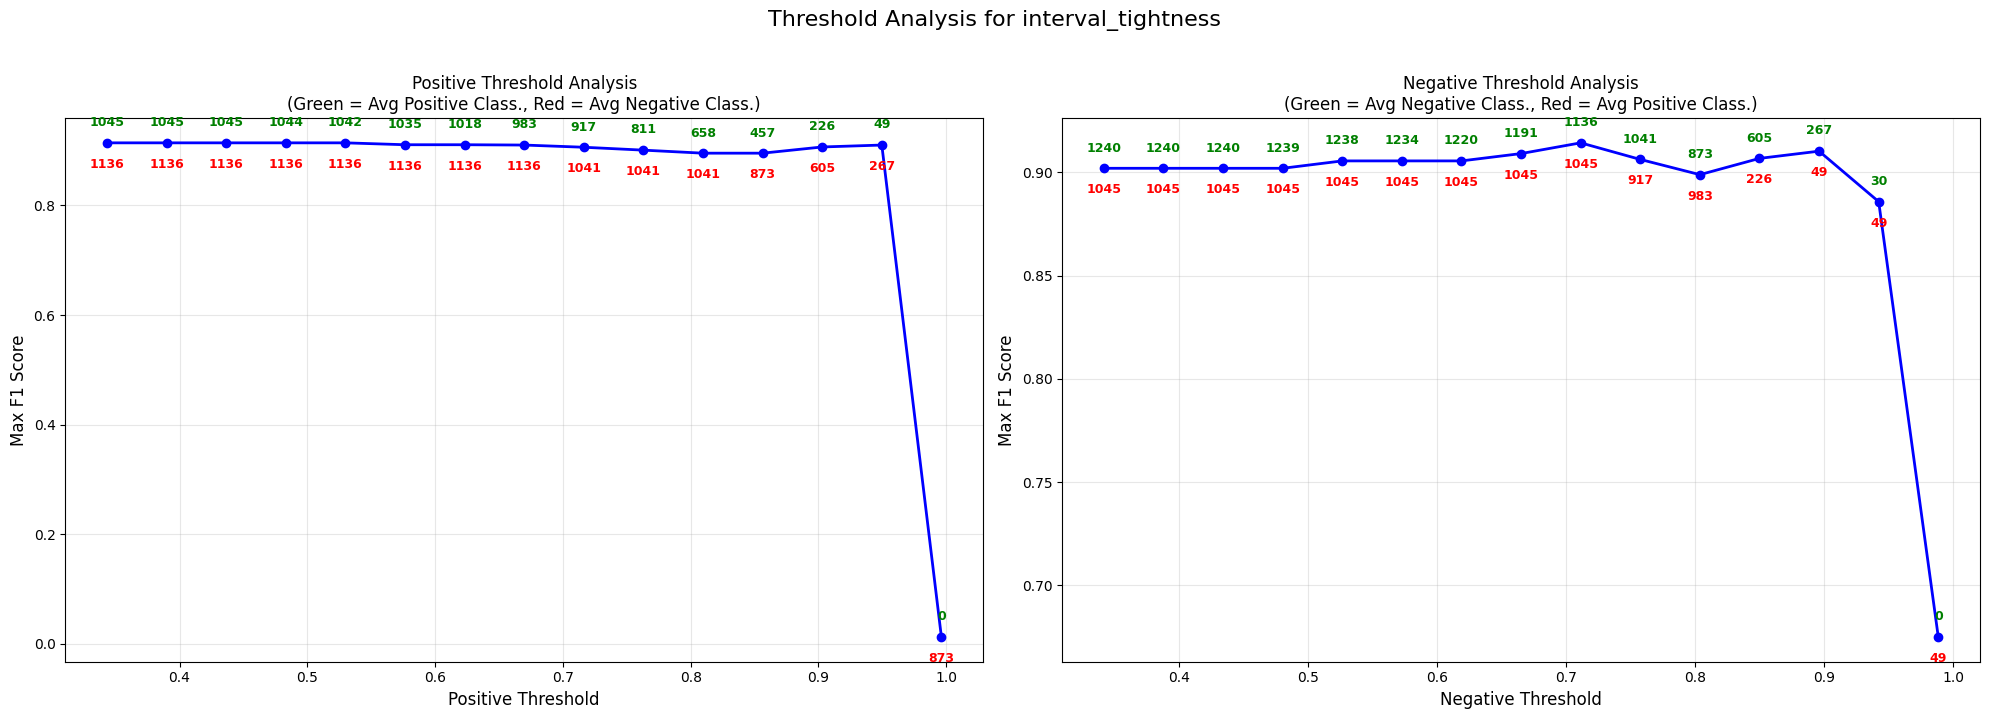


Metric: description_volume

Positive Threshold Analysis:
  Best threshold: 0.001875
  Max F1 score: 0.905537
  Avg positive classifications: 1042
  Avg negative classifications: 1238

Negative Threshold Analysis:
  Best threshold: 0.002542
  Max F1 score: 0.905537
  Avg negative classifications: 1238
  Avg positive classifications: 1042


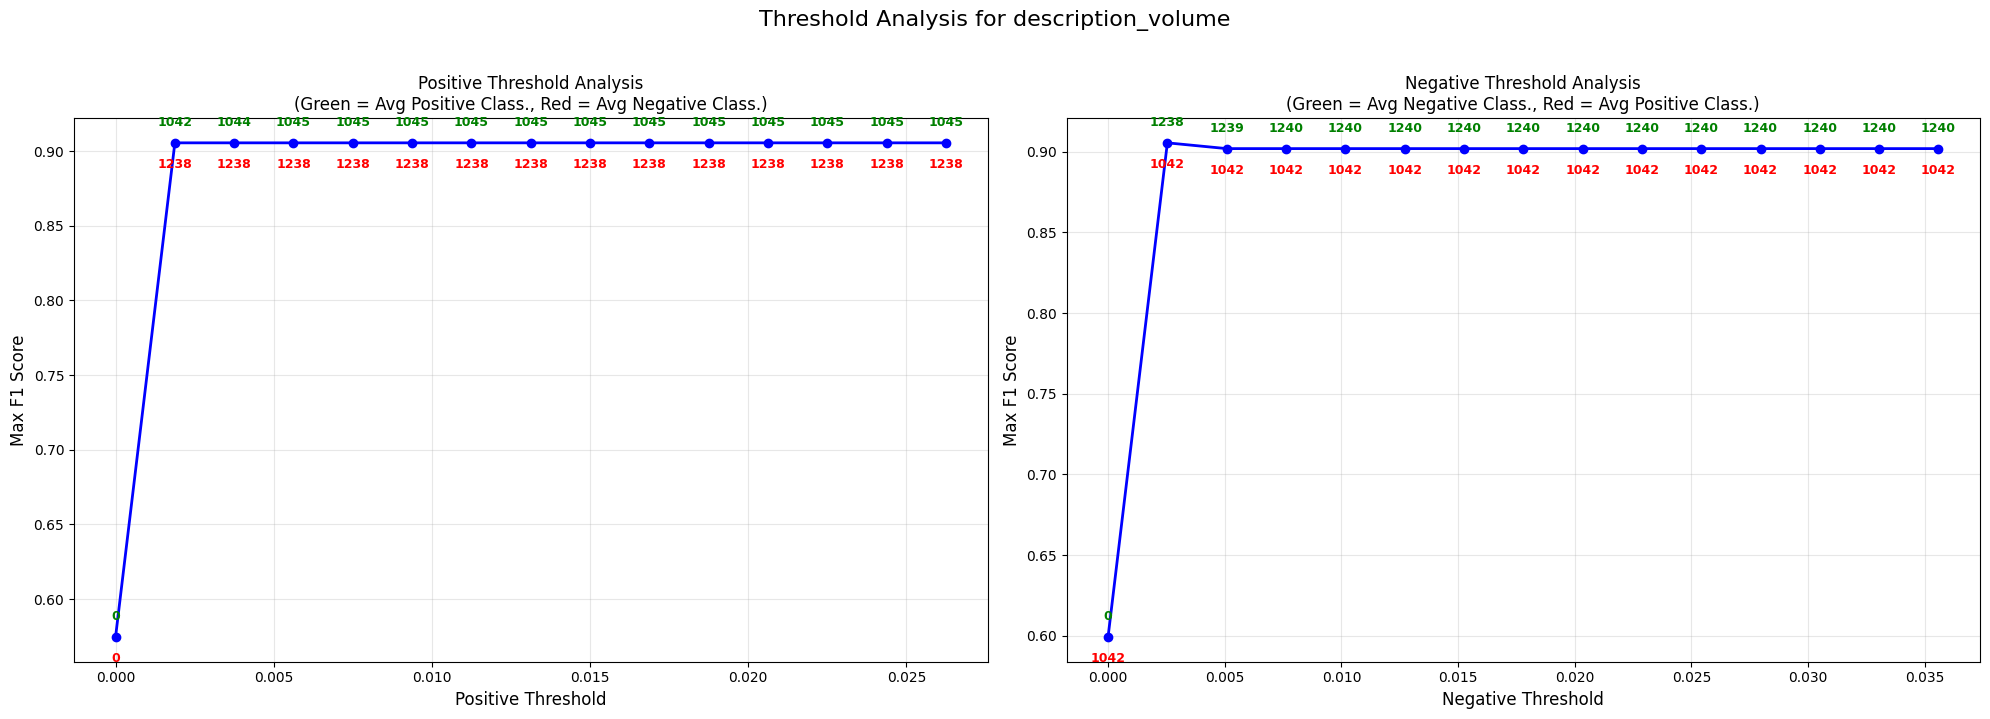


Metric: simplicity_prior

Positive Threshold Analysis:
  Best threshold: 0.715771
  Max F1 score: 0.915888
  Avg positive classifications: 1027
  Avg negative classifications: 1076

Negative Threshold Analysis:
  Best threshold: 0.795793
  Max F1 score: 0.915888
  Avg negative classifications: 1076
  Avg positive classifications: 1027


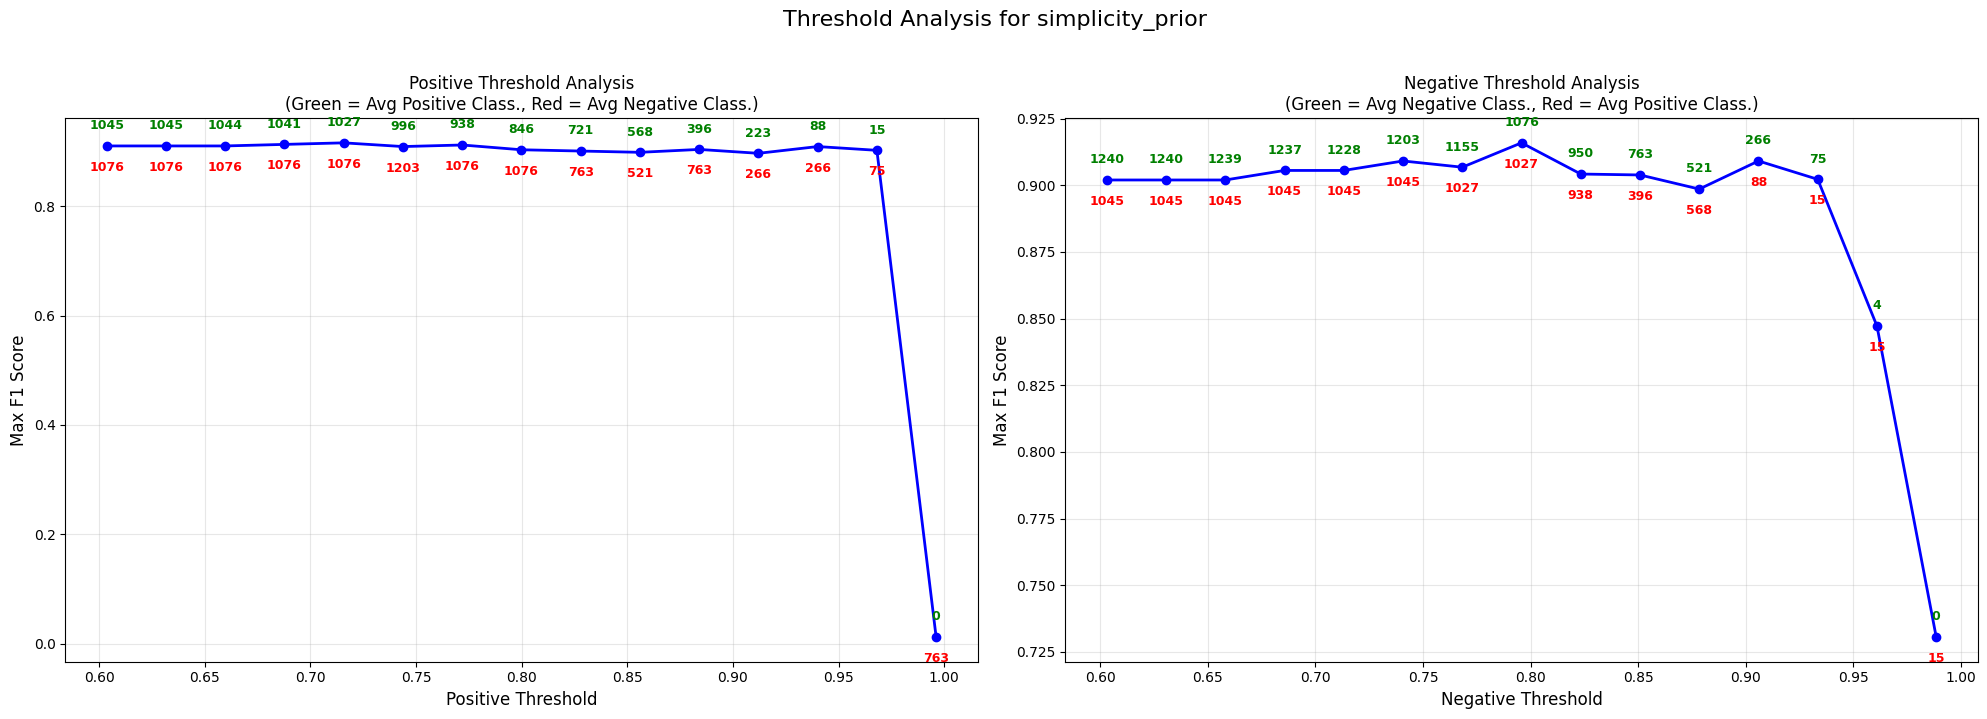


Metric: query_binary_similarity

Positive Threshold Analysis:
  Best threshold: 1.000000
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 1.000000
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


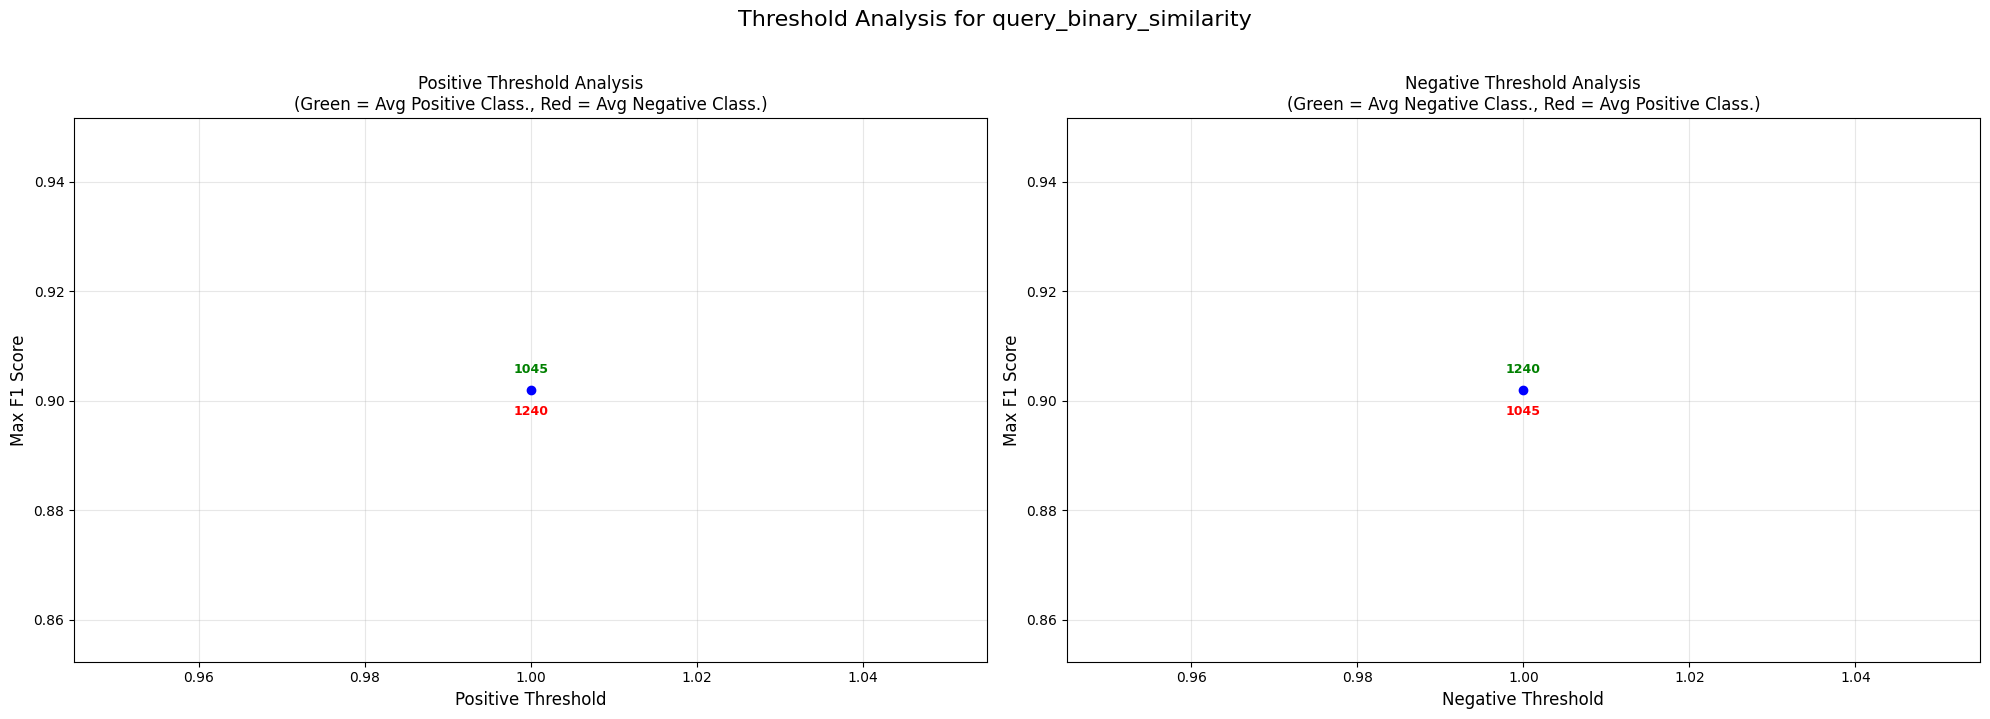


Metric: query_numeric_similarity

Positive Threshold Analysis:
  Best threshold: 0.343262
  Max F1 score: 0.914286
  Avg positive classifications: 1045
  Avg negative classifications: 1136

Negative Threshold Analysis:
  Best threshold: 0.711245
  Max F1 score: 0.914286
  Avg negative classifications: 1136
  Avg positive classifications: 1045


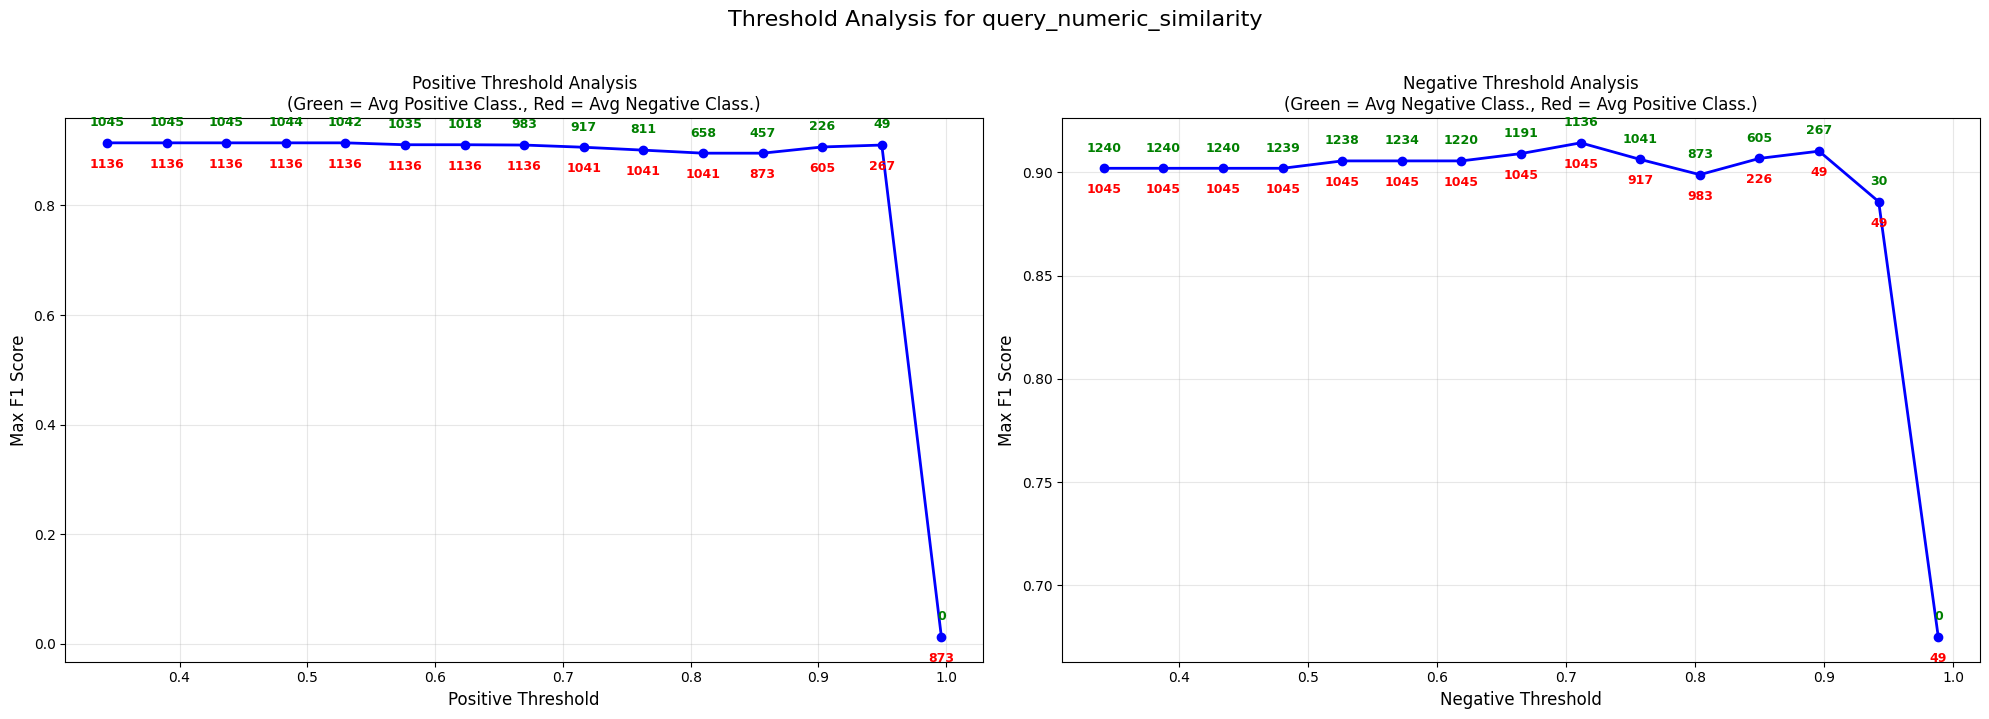


Metric: query_similarity

Positive Threshold Analysis:
  Best threshold: 0.343262
  Max F1 score: 0.914286
  Avg positive classifications: 1045
  Avg negative classifications: 1136

Negative Threshold Analysis:
  Best threshold: 0.711245
  Max F1 score: 0.914286
  Avg negative classifications: 1136
  Avg positive classifications: 1045


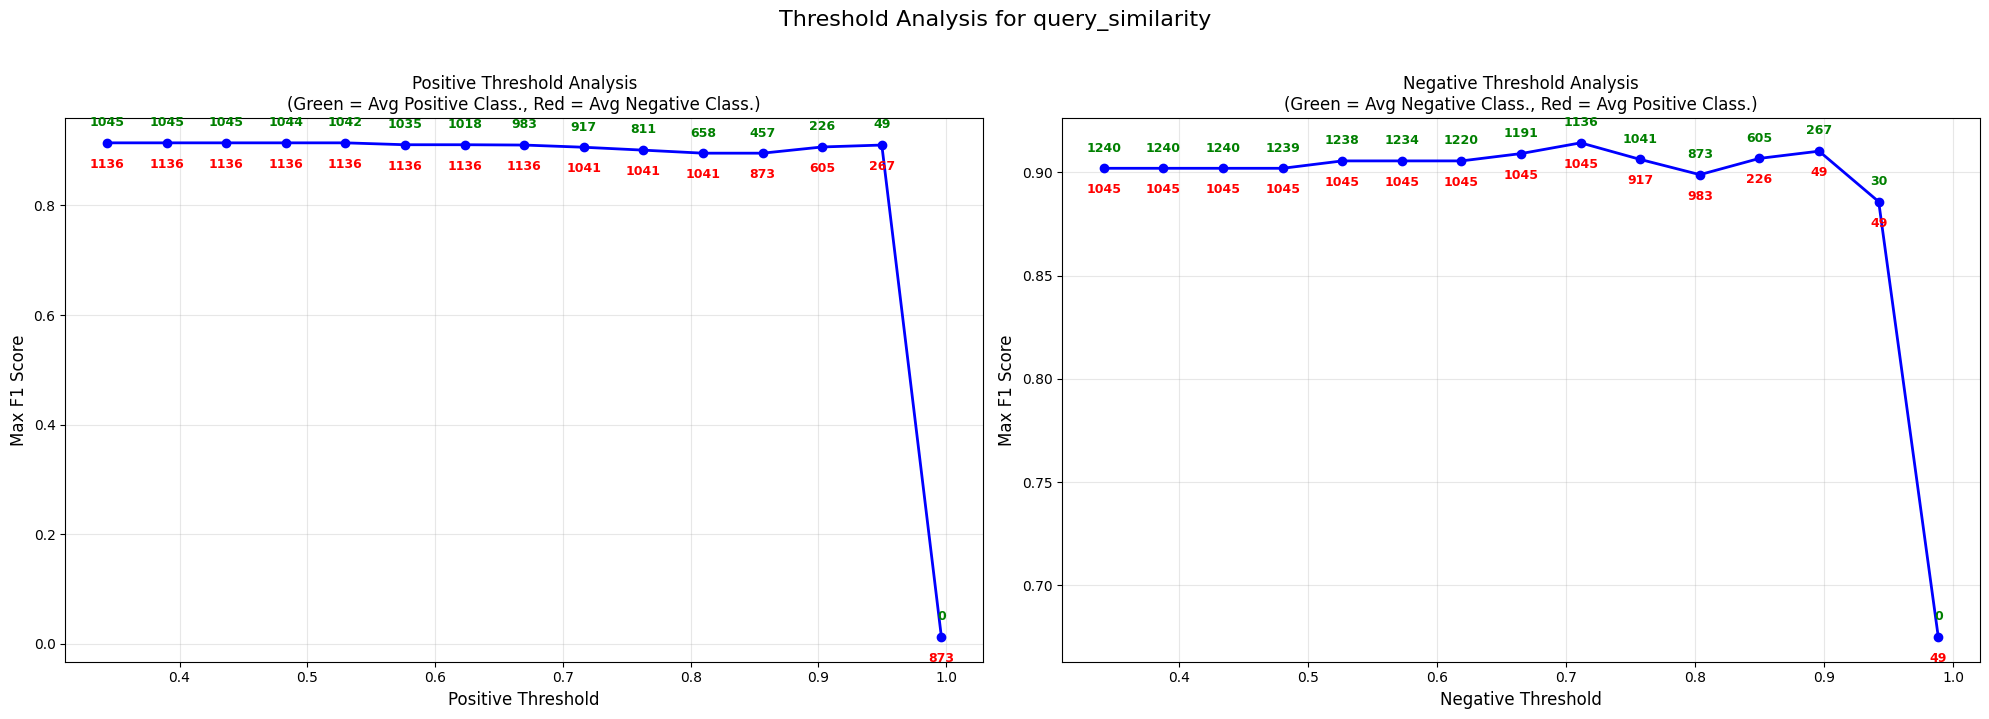


Metric: query_weighted_precision

Positive Threshold Analysis:
  Best threshold: 0.197498
  Max F1 score: 0.920245
  Avg positive classifications: 1045
  Avg negative classifications: 1046

Negative Threshold Analysis:
  Best threshold: 0.602005
  Max F1 score: 0.920245
  Avg negative classifications: 1046
  Avg positive classifications: 1045


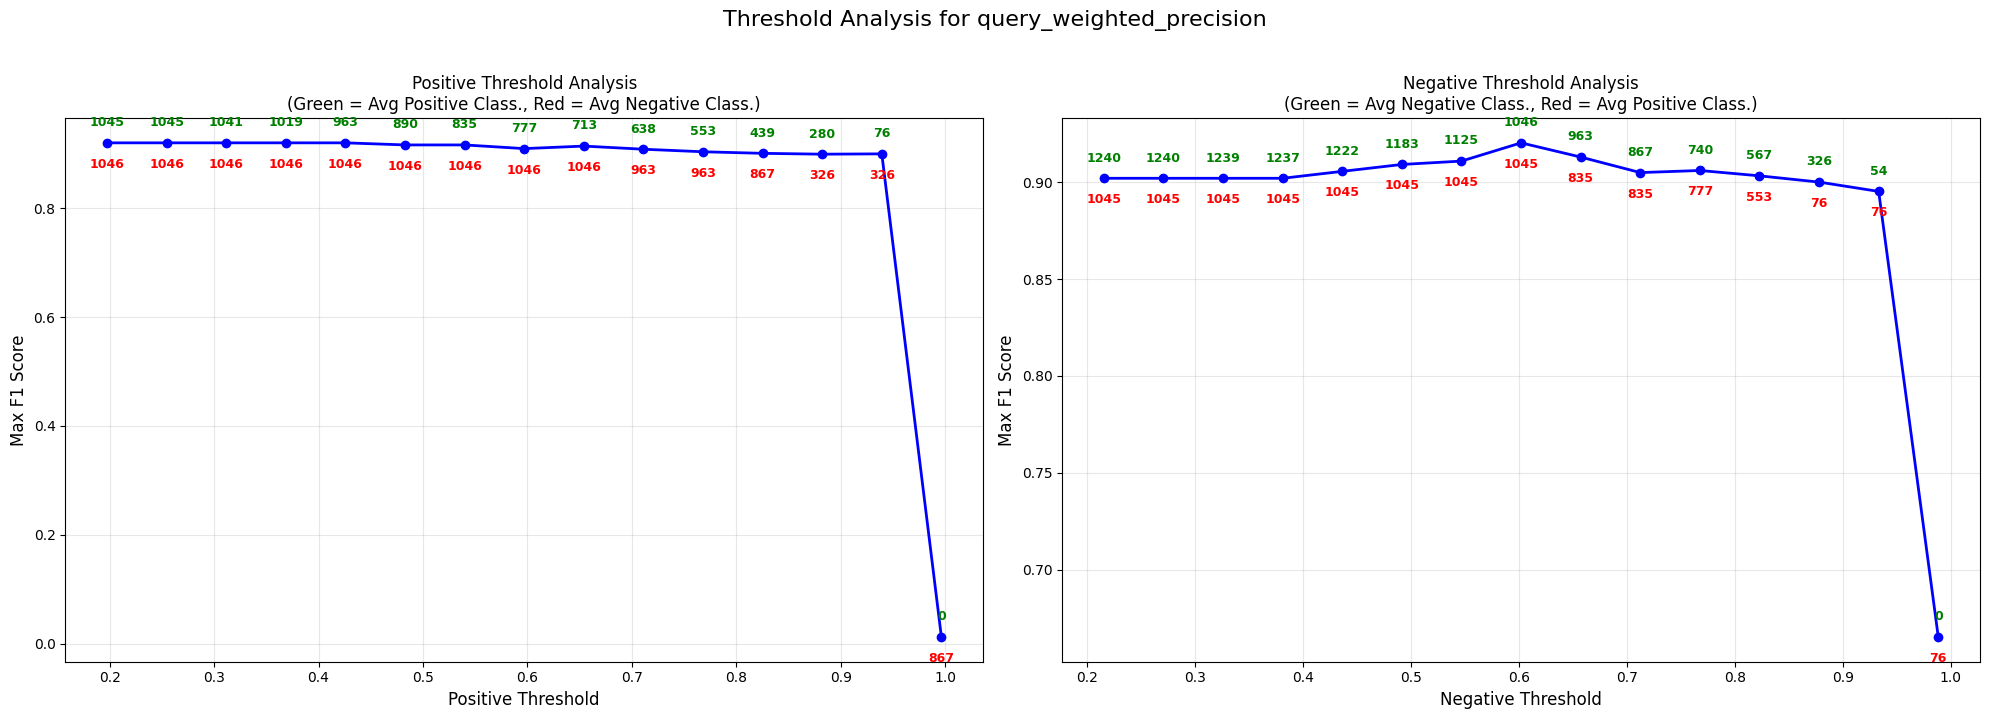


Metric: query_weighted_wracc

Positive Threshold Analysis:
  Best threshold: 0.000021
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 0.000042
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


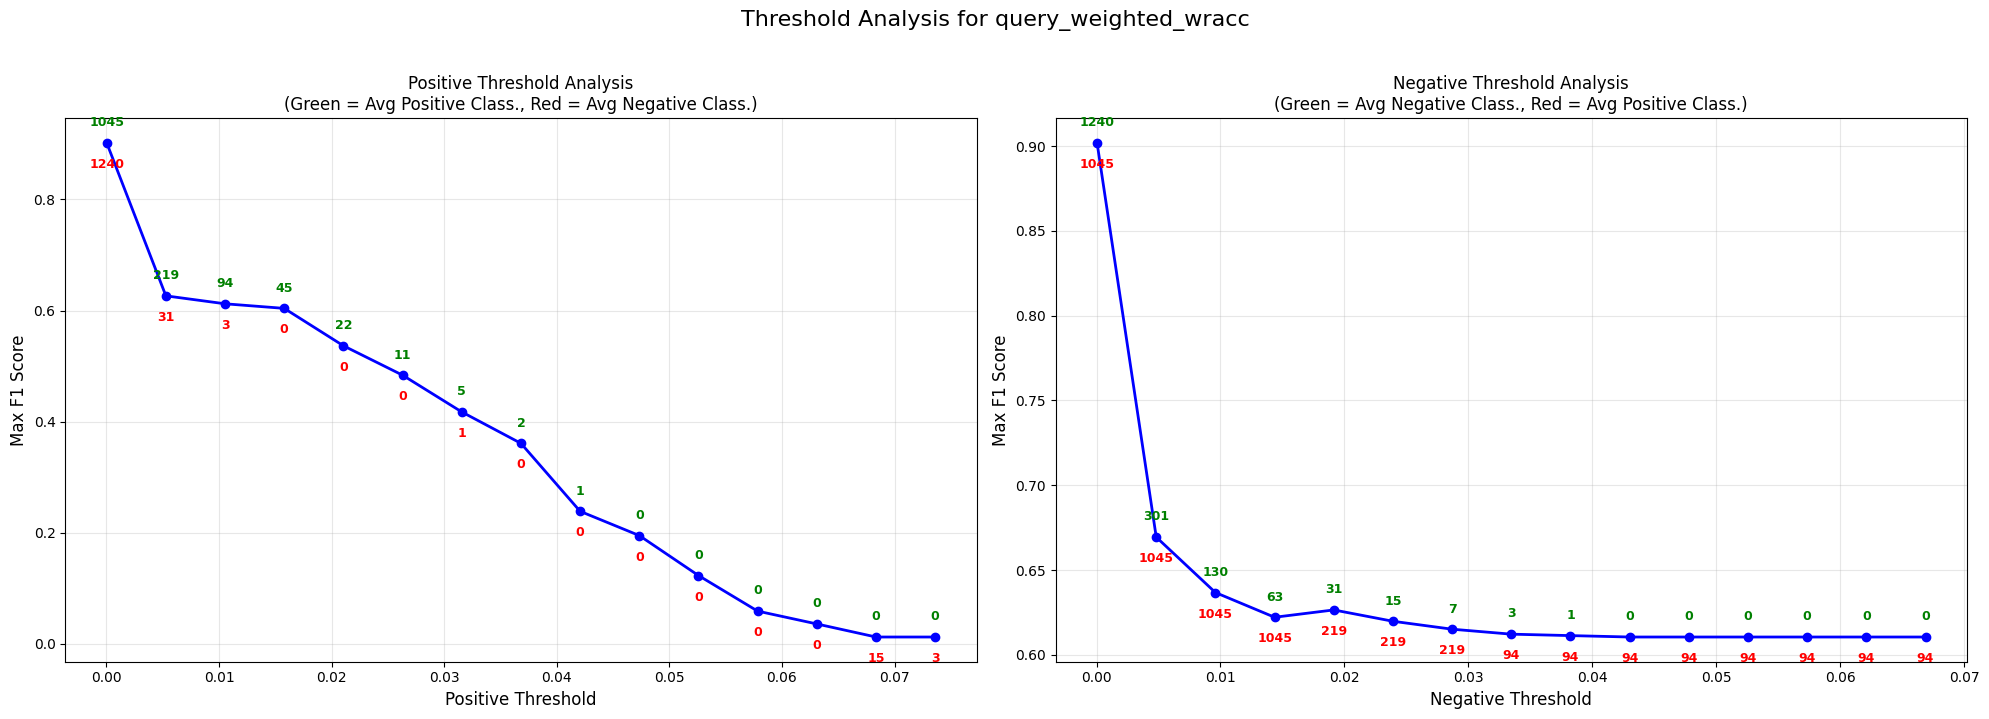


Metric: stability

Positive Threshold Analysis:
  Best threshold: 0.001953
  Max F1 score: 0.903226
  Avg positive classifications: 1045
  Avg negative classifications: 1223

Negative Threshold Analysis:
  Best threshold: 0.005859
  Max F1 score: 0.903226
  Avg negative classifications: 1223
  Avg positive classifications: 1045


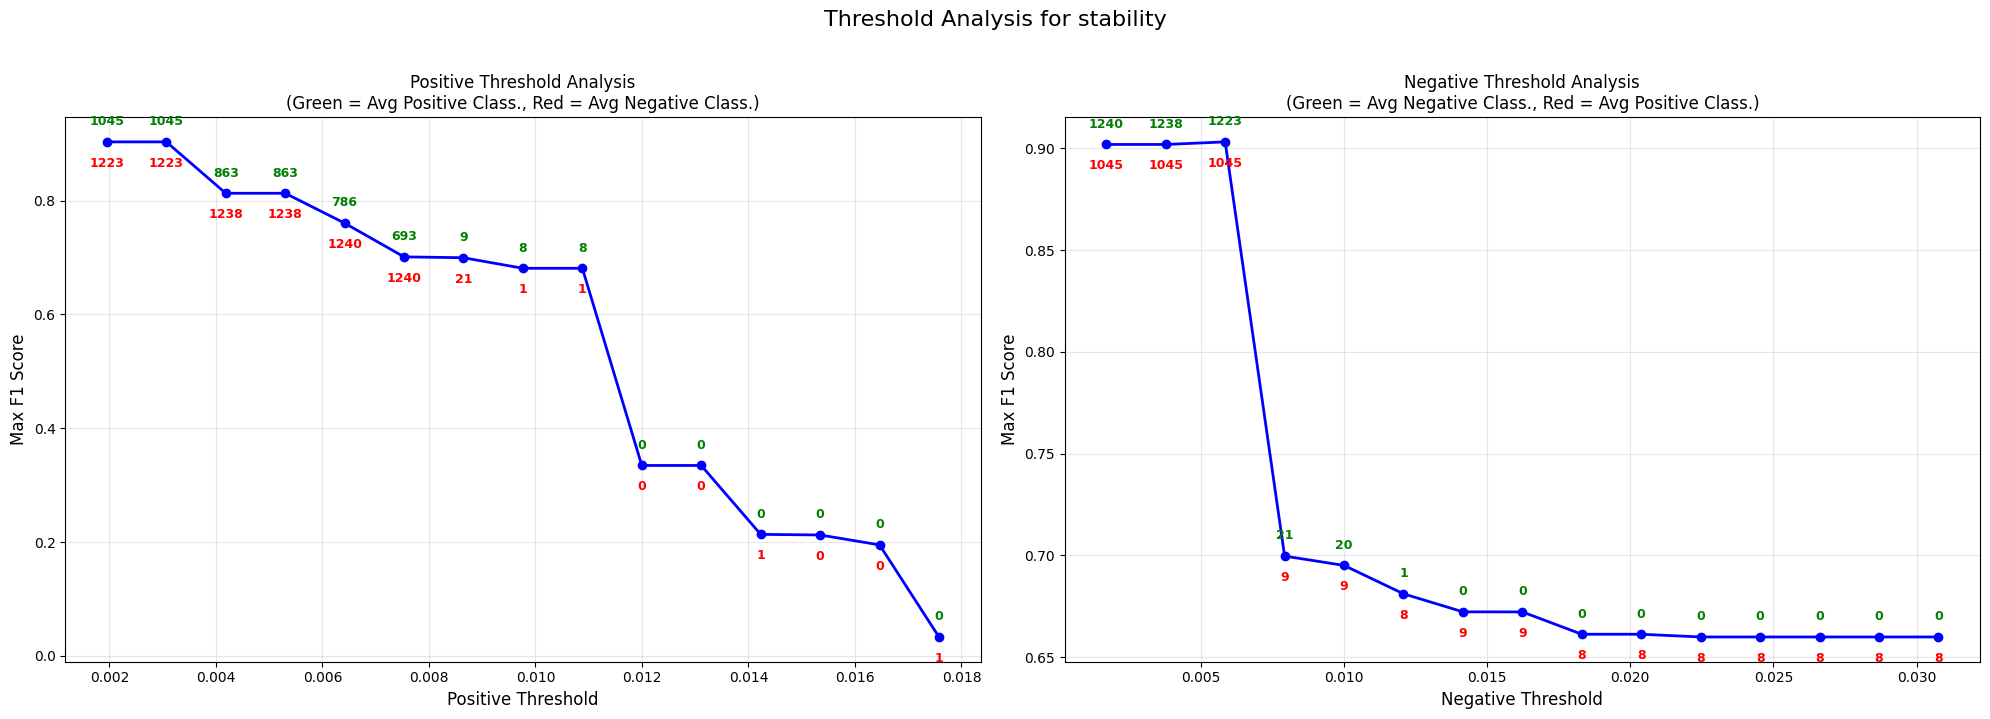


Metric: robustness

Positive Threshold Analysis:
  Best threshold: 0.001953
  Max F1 score: 0.903226
  Avg positive classifications: 1045
  Avg negative classifications: 1223

Negative Threshold Analysis:
  Best threshold: 0.005859
  Max F1 score: 0.903226
  Avg negative classifications: 1223
  Avg positive classifications: 1045


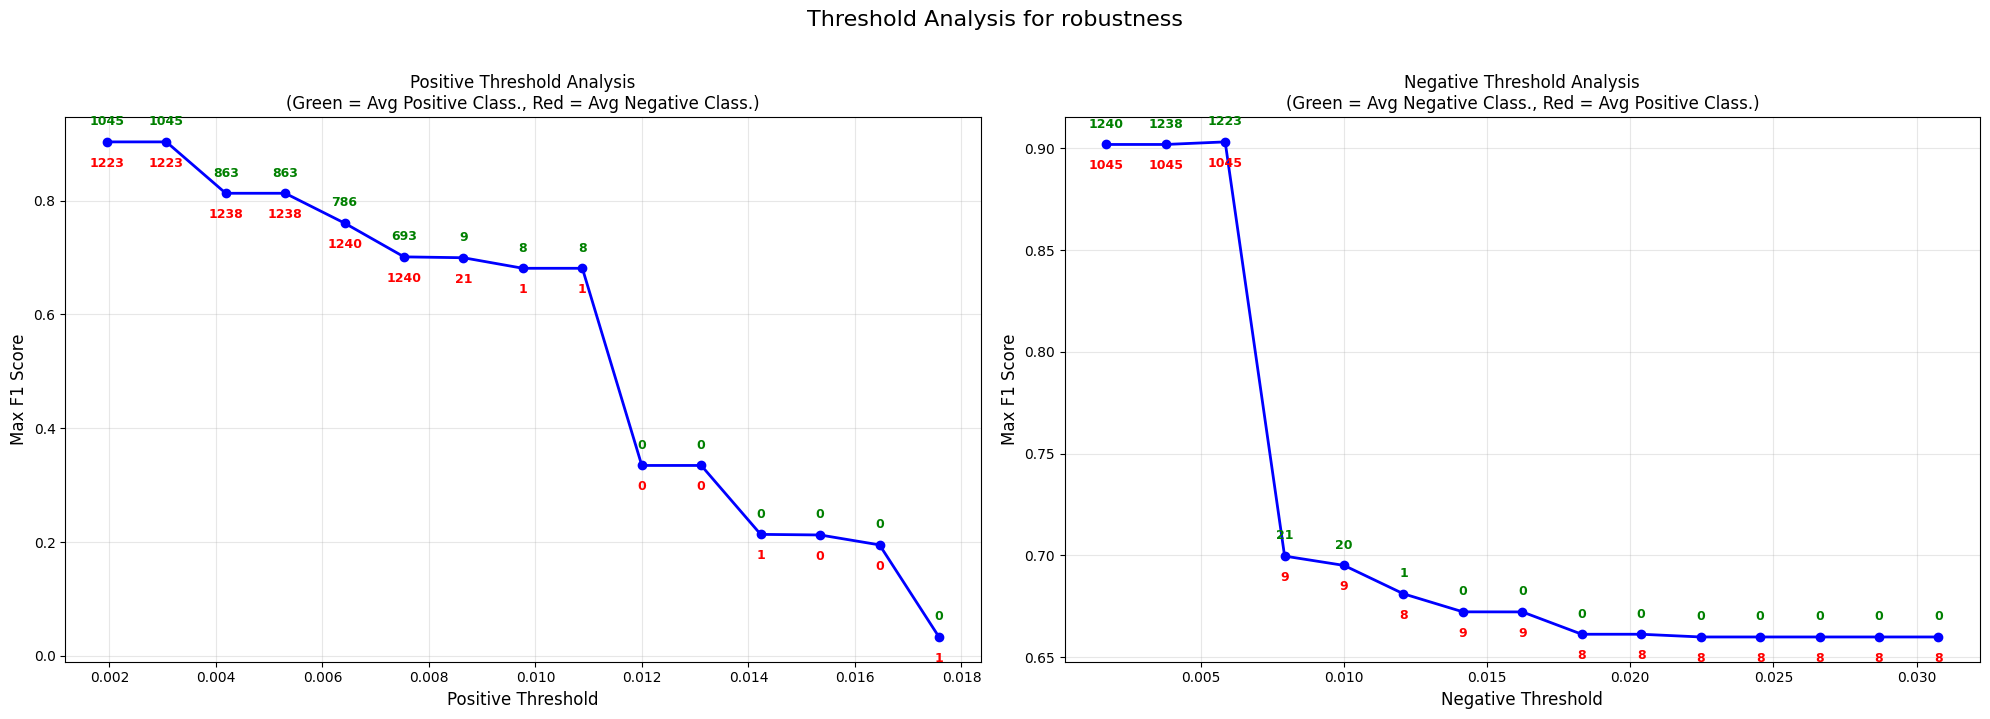


Metric: delta_stability

Positive Threshold Analysis:
  Best threshold: 1.000000
  Max F1 score: 0.901961
  Avg positive classifications: 1045
  Avg negative classifications: 1240

Negative Threshold Analysis:
  Best threshold: 1.000000
  Max F1 score: 0.901961
  Avg negative classifications: 1240
  Avg positive classifications: 1045


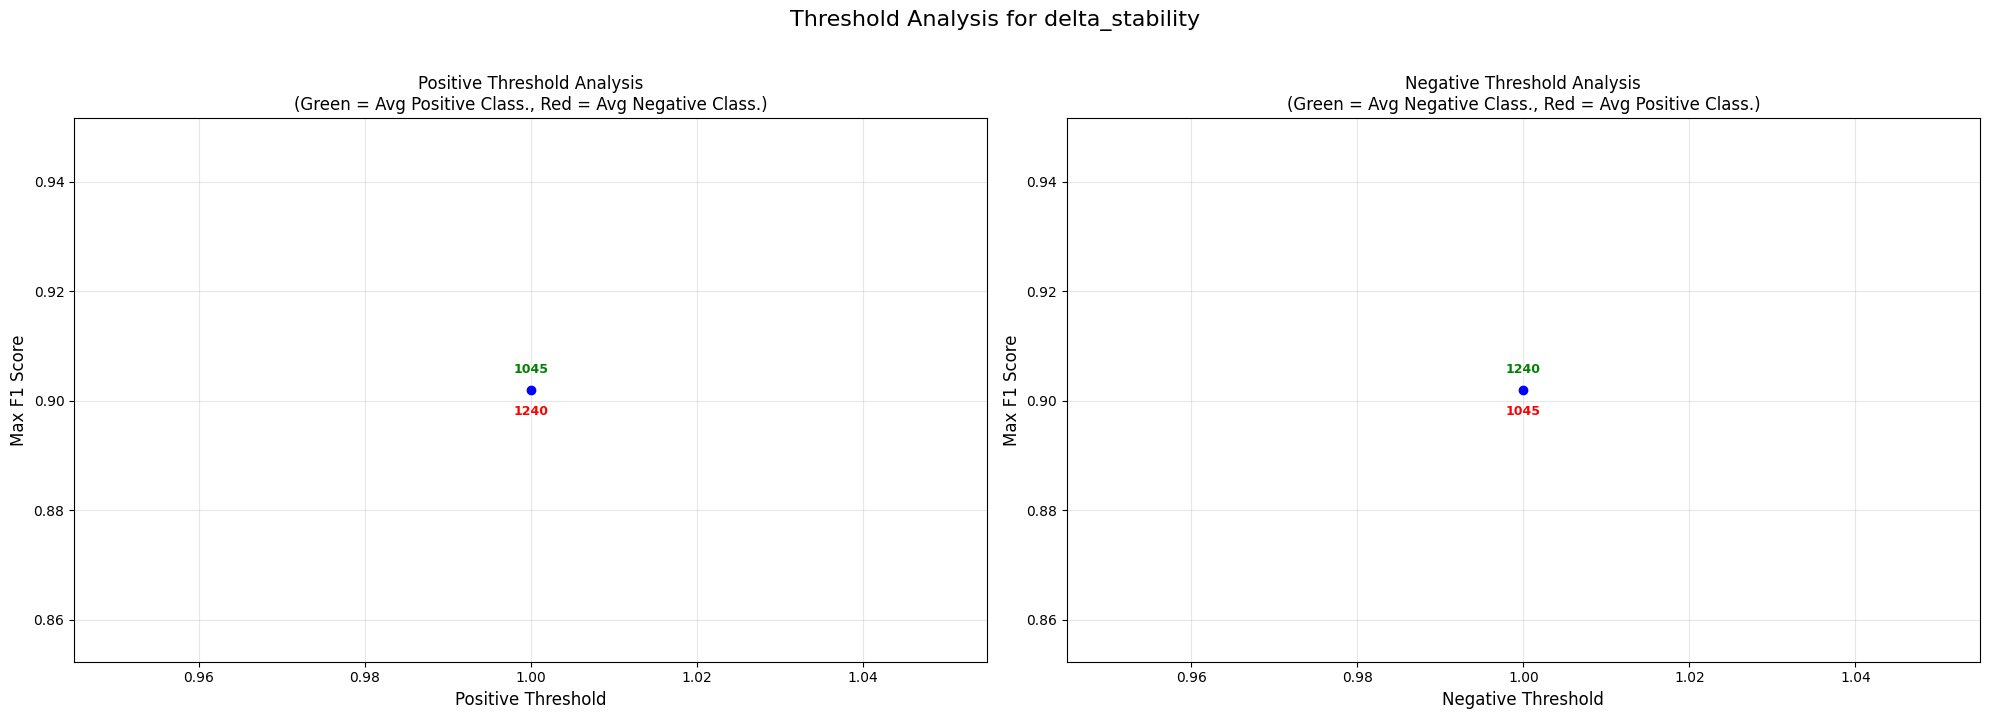

In [8]:
# Plot all metrics
for metric in metrics:
    print(f"\n{'='*80}")
    print(f"Metric: {metric}")
    print(f"{'='*80}")
    plot_both_thresholds_vs_f1(df, metric)

In [10]:
# Summary: Best F1-score for each metric
best_per_metric = []
for metric in df['metric_name'].unique():
    metric_data = df[df['metric_name'] == metric]
    best_row = metric_data.loc[metric_data['F1-score'].idxmax()]
    best_per_metric.append({
        'metric_name': metric,
        'best_f1_score': best_row['F1-score'],
        'best_pos_threshold': best_row['pos_threshold'],
        'best_neg_threshold': best_row['neg_threshold'],
        'avg_pos_classifications': int(best_row['avg_positive_classifications']),
        'avg_neg_classifications': int(best_row['avg_negative_classifications'])
    })

summary_df = pd.DataFrame(best_per_metric).sort_values('best_f1_score', ascending=False)
print("Best F1-score for each metric:\n")
summary_df

Best F1-score for each metric:



,metric_name,best_f1_score,best_pos_threshold,best_neg_threshold,avg_pos_classifications,avg_neg_classifications
3,precision,0.925466,0.500000,0.682540,1045,1167
4,lift,0.925466,1.168712,1.192879,1045,1167
20,query_weighted_precision,0.920245,0.197498,0.602005,1045,1046
0,opposers_covered,0.916129,56.214286,38.000000,992,1166
2,error_rate,0.916129,0.028652,0.025903,992,1166
16,simplicity_prior,0.915888,0.715771,0.795793,1027,1076
19,query_similarity,0.914286,0.343262,0.711245,1045,1136
18,query_numeric_similarity,0.914286,0.343262,0.711245,1045,1136
14,interval_tightness,0.914286,0.343262,0.711245,1045,1136
11,log_odds_ratio,0.909639,53.571429,65.476190,63,111


## Results

- for `information gain` with threshold **0.03** we can reduce the number of classes to 46 for positive and 73 for negative and keep f1 score higher **0.7**
- for `log_odds_ratio` with threshold **>200** for negative classifiers we can reduce the number of classes to 0 for positive and 22 for negative and keep f1 score higher **0.87**
- for `interval_tightness` with threshold **0.94** for negtive classifiers we can reduce the number of classes to 30 for positive and 49 for negative and keep f1 score higher **0.87**
- for `simplicity prior` with threshold **0.96** for negtive classifiers we can reduce the number of classes to 4 for positive and 15 for negative and keep f1 score **0.85**
- for `query numeric similarity` with threshold **0.94** for negtive classifiers we can reduce the number of classes to 30 for positive and 49 for negative and keep f1 score **0.87** and the same for metric `query similarity`
- for `stability` with threshold **0.011** for positive classifiers we can reduce the number of classes to 8 for positive and 1 for negative and keep f1 score is about **0.7**  and the same for `robustness`